# Fund Liquidity Mismatch Stress Engine

This notebook builds a fund liquidity stress testing engine.

The engine compares:

- asset-side liquidity: how quickly the fund can turn holdings into cash
- liability-side liquidity: how quickly investors can redeem

It then simulates redemption shocks, builds a liquidation waterfall, calculates fire-sale costs, measures liquidity coverage, checks cash shortfalls, and produces a model-suggested escalation outcome.

The project is designed as a fund risk / asset management operations workflow, not a trading model.


## Workflow

1. Create fund, holdings and investor base
2. Classify holdings into liquidity buckets
3. Define redemption shock scenarios
4. Define market impact and fire-sale assumptions
5. Validate liquidity data
6. Build liquidation waterfall
7. Calculate cash raised and fire-sale costs
8. Calculate liquidity coverage ratios
9. Analyse remaining portfolio liquidity
10. Produce model-suggested escalation outcome
11. Export Excel reporting pack
12. Build Streamlit dashboard


In [1]:
# ============================================================
# 1. Project Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

np.random.seed(42)

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

STRESS_DATE = pd.Timestamp("2027-03-31")
PROCESSING_TIMESTAMP = pd.Timestamp("2027-03-31 18:00:00")
BASE_CURRENCY = "GBP"

# Liquidity horizons used for stress reporting
LIQUIDITY_HORIZONS = [1, 3, 7, 30, 90]

# Base thresholds for model-suggested escalation
ACCEPTABLE_FIRE_SALE_COST_BPS = 50
MATERIAL_FIRE_SALE_COST_BPS = 150
SEVERE_SHORTFALL_THRESHOLD = 0.25

print("Fund Liquidity Mismatch Stress Engine loaded.")
print(f"Stress date:       {STRESS_DATE.date()}")
print(f"Base currency:     {BASE_CURRENCY}")
print(f"Output folder:     {OUTPUT_DIR}")


Fund Liquidity Mismatch Stress Engine loaded.
Stress date:       2027-03-31
Base currency:     GBP
Output folder:     /Users/ludmilaaboud/Desktop/MSc HW/Others/fund-liquidity-stress-engine/outputs


In [2]:
# ============================================================
# 2. Fund, Holdings and Investor Base Creation
# ============================================================

# ------------------------------------------------------------
# Fund master
# ------------------------------------------------------------

fund_master = pd.DataFrame([
    {
        "fund_id": "FUND-LIQ-001",
        "fund_name": "Global Income Opportunities Fund",
        "fund_type": "Open-Ended Multi-Asset Fund",
        "base_currency": BASE_CURRENCY,
        "dealing_frequency": "Daily",
        "redemption_notice_days": 1,
        "valuation_frequency": "Daily",
        "stress_date": STRESS_DATE,
        "fund_manager": "Sterling Bridge Asset Management",
        "depositary": "Albion Global Depositary",
        "administrator": "Northstar Fund Services",
    }
])

# ------------------------------------------------------------
# Holdings universe
# ------------------------------------------------------------

holdings_data = [
    # Cash / cash equivalents
    ["H001", "CASH_GBP", "GBP Operating Cash", "Cash", "Cash", "GBP", 100_000_000, "T+0", 0, 0, 0, 0, 100_000_000, True],
    ["H002", "UKT-BILL", "UK Treasury Bill 3M", "Treasury Bill", "Government", "GBP", 30_000_000, "T+1", 1, 500_000_000, 6.0, 2, 20_000_000_000, True],
    ["H003", "STER-MMF", "Sterling Liquidity Fund", "Money Market Fund", "Cash Equivalent", "GBP", 25_000_000, "T+1", 1, 250_000_000, 10.0, 3, 8_000_000_000, True],

    # Large-cap equities / liquid ETFs
    ["H004", "AZN", "AstraZeneca PLC", "Equity", "Healthcare", "GBP", 55_000_000, "T+1", 1, 600_000_000, 9.2, 6, 180_000_000_000, True],
    ["H005", "SHEL", "Shell PLC", "Equity", "Energy", "GBP", 50_000_000, "T+1", 1, 700_000_000, 7.1, 5, 170_000_000_000, True],
    ["H006", "HSBA", "HSBC Holdings PLC", "Equity", "Financials", "GBP", 40_000_000, "T+1", 1, 500_000_000, 8.0, 7, 120_000_000_000, True],
    ["H007", "AAPL", "Apple Inc.", "Equity", "Technology", "USD", 60_000_000, "T+1", 1, 850_000_000, 7.1, 4, 2_600_000_000_000, True],
    ["H008", "MSFT", "Microsoft Corp.", "Equity", "Technology", "USD", 55_000_000, "T+1", 1, 900_000_000, 6.1, 4, 2_900_000_000_000, True],
    ["H009", "VUSA", "Vanguard S&P 500 ETF", "ETF", "Index Exposure", "GBP", 35_000_000, "T+1", 1, 300_000_000, 11.7, 5, 35_000_000_000, True],

    # T+3 assets
    ["H010", "MIDUK", "UK Mid-Cap Basket", "Equity", "UK Mid-Cap", "GBP", 35_000_000, "T+3", 3, 80_000_000, 43.8, 18, 2_500_000_000, True],
    ["H011", "EUGROW", "European Growth Basket", "Equity", "European Equity", "EUR", 32_000_000, "T+3", 3, 75_000_000, 42.7, 20, 2_200_000_000, True],
    ["H012", "HEALTHMID", "Healthcare Mid-Cap Basket", "Equity", "Healthcare", "GBP", 28_000_000, "T+3", 3, 65_000_000, 43.1, 22, 1_800_000_000, True],
    ["H013", "TECHMID", "Technology Mid-Cap Basket", "Equity", "Technology", "USD", 30_000_000, "T+3", 3, 70_000_000, 42.9, 25, 1_900_000_000, True],
    ["H014", "REITLIQ", "Listed REIT Basket", "REIT", "Real Estate", "GBP", 25_000_000, "T+3", 3, 55_000_000, 45.5, 28, 1_400_000_000, True],

    # T+7 investment-grade credit
    ["H015", "IGBANK29", "Investment Grade Bank Bond 2029", "Bond", "Financial Credit", "GBP", 45_000_000, "T+7", 7, 18_000_000, 250.0, 38, 900_000_000, True],
    ["H016", "IGUTIL30", "Investment Grade Utility Bond 2030", "Bond", "Utility Credit", "GBP", 35_000_000, "T+7", 7, 12_000_000, 291.7, 42, 750_000_000, True],
    ["H017", "IGTEL31", "Investment Grade Telecom Bond 2031", "Bond", "Telecom Credit", "EUR", 30_000_000, "T+7", 7, 10_000_000, 300.0, 45, 680_000_000, True],
    ["H018", "IGIND32", "Investment Grade Industrial Bond 2032", "Bond", "Industrial Credit", "USD", 35_000_000, "T+7", 7, 10_000_000, 350.0, 48, 720_000_000, True],

    # T+30 stressed liquidity assets
    ["H019", "HYENERGY28", "High Yield Energy Bond 2028", "Bond", "High Yield Credit", "USD", 35_000_000, "T+30", 30, 3_500_000, 1000.0, 95, 450_000_000, True],
    ["H020", "HYRETAIL29", "High Yield Retail Bond 2029", "Bond", "High Yield Credit", "GBP", 25_000_000, "T+30", 30, 2_000_000, 1250.0, 115, 300_000_000, True],
    ["H021", "EMSOV33", "Emerging Market Sovereign Bond 2033", "Bond", "Emerging Market Debt", "USD", 30_000_000, "T+30", 30, 4_000_000, 750.0, 105, 600_000_000, True],
    ["H022", "SCALPHA", "Small-Cap Alpha Equity", "Equity", "Small Cap", "GBP", 28_000_000, "T+30", 30, 4_500_000, 622.2, 130, 500_000_000, True],
    ["H023", "PRIVCRED", "Private Credit Note", "Private Credit", "Private Credit", "GBP", 32_000_000, "T+30", 30, 500_000, 6400.0, 180, 120_000_000, False],

    # T+90+ illiquid / hard-to-sell assets
    ["H024", "UKPROP", "UK Property SPV", "Property", "Real Estate", "GBP", 65_000_000, "T+90+", 90, 0, np.nan, 300, 250_000_000, False],
    ["H025", "UNLISTGROW", "Unlisted Growth Fund", "Private Equity", "Private Markets", "GBP", 30_000_000, "T+90+", 90, 0, np.nan, 400, 150_000_000, False],
    ["H026", "SIDELOAN", "Side-Pocket Loan", "Illiquid Credit", "Private Credit", "GBP", 10_000_000, "T+90+", 90, 0, np.nan, 550, 50_000_000, False],
]

holdings = pd.DataFrame(
    holdings_data,
    columns=[
        "holding_id",
        "ticker",
        "asset_name",
        "asset_class",
        "sector",
        "currency",
        "market_value_gbp",
        "liquidity_bucket",
        "bucket_days",
        "avg_daily_volume_gbp",
        "pct_of_adv_held",
        "bid_ask_spread_bps",
        "issue_size_or_free_float_gbp",
        "listed_or_daily_traded",
    ],
)

fund_nav_gbp = holdings["market_value_gbp"].sum()
holdings["portfolio_weight"] = holdings["market_value_gbp"] / fund_nav_gbp

# ------------------------------------------------------------
# Investor base / liability-side liquidity
# ------------------------------------------------------------

investor_base = pd.DataFrame([
    {
        "investor_type": "Retail Direct",
        "pct_of_aum": 0.30,
        "notice_period_days": 1,
        "historical_redemption_volatility": 0.08,
        "stickiness_score": 0.55,
        "behaviour_note": "Numerous small investors, but sensitive to performance and headlines.",
    },
    {
        "investor_type": "Platform Aggregated Retail",
        "pct_of_aum": 0.35,
        "notice_period_days": 1,
        "historical_redemption_volatility": 0.12,
        "stickiness_score": 0.45,
        "behaviour_note": "Large platform flows can move together during fund outflows.",
    },
    {
        "investor_type": "Wealth Managers",
        "pct_of_aum": 0.15,
        "notice_period_days": 2,
        "historical_redemption_volatility": 0.10,
        "stickiness_score": 0.50,
        "behaviour_note": "Can redeem in model portfolio reallocations.",
    },
    {
        "investor_type": "Institutional Seed Investor",
        "pct_of_aum": 0.12,
        "notice_period_days": 5,
        "historical_redemption_volatility": 0.18,
        "stickiness_score": 0.35,
        "behaviour_note": "Lower frequency but larger single-ticket redemption risk.",
    },
    {
        "investor_type": "Pension / Consultant Channel",
        "pct_of_aum": 0.08,
        "notice_period_days": 5,
        "historical_redemption_volatility": 0.06,
        "stickiness_score": 0.70,
        "behaviour_note": "More stable but subject to governance-driven redemption decisions.",
    },
])

investor_base["aum_gbp"] = investor_base["pct_of_aum"] * fund_nav_gbp

# ------------------------------------------------------------
# Redemption shock scenarios
# ------------------------------------------------------------

redemption_scenarios = pd.DataFrame([
    {
        "scenario_id": "S1",
        "scenario_name": "Mild Outflow",
        "redemption_pct_of_nav": 0.05,
        "time_horizon_days": 3,
        "redemption_trigger": "Normal monthly outflow with moderate performance pressure",
    },
    {
        "scenario_id": "S2",
        "scenario_name": "Elevated Outflow",
        "redemption_pct_of_nav": 0.10,
        "time_horizon_days": 7,
        "redemption_trigger": "Platform-driven redemption wave after underperformance",
    },
    {
        "scenario_id": "S3",
        "scenario_name": "Stress Redemption",
        "redemption_pct_of_nav": 0.20,
        "time_horizon_days": 7,
        "redemption_trigger": "Sector shock and negative press triggering rapid outflows",
    },
    {
        "scenario_id": "S4",
        "scenario_name": "Crisis Redemption",
        "redemption_pct_of_nav": 0.30,
        "time_horizon_days": 7,
        "redemption_trigger": "Severe investor run with concentrated platform and institutional exits",
    },
])

redemption_scenarios["redemption_amount_gbp"] = (
    redemption_scenarios["redemption_pct_of_nav"] * fund_nav_gbp
)

# ------------------------------------------------------------
# Summary tables
# ------------------------------------------------------------

liquidity_bucket_summary = (
    holdings
    .groupby(["liquidity_bucket", "bucket_days"], as_index=False)
    .agg(
        holding_count=("holding_id", "count"),
        market_value_gbp=("market_value_gbp", "sum"),
        avg_bid_ask_spread_bps=("bid_ask_spread_bps", "mean"),
    )
    .sort_values("bucket_days")
)

liquidity_bucket_summary["portfolio_weight"] = (
    liquidity_bucket_summary["market_value_gbp"] / fund_nav_gbp
)

asset_class_summary = (
    holdings
    .groupby("asset_class", as_index=False)
    .agg(
        holding_count=("holding_id", "count"),
        market_value_gbp=("market_value_gbp", "sum"),
        avg_bucket_days=("bucket_days", "mean"),
        avg_bid_ask_spread_bps=("bid_ask_spread_bps", "mean"),
    )
    .sort_values("market_value_gbp", ascending=False)
)

asset_class_summary["portfolio_weight"] = (
    asset_class_summary["market_value_gbp"] / fund_nav_gbp
)

investor_base_summary = investor_base.copy()
investor_base_summary["aum_gbp"] = investor_base_summary["aum_gbp"].round(2)

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------

print("=" * 80)
print("FUND, HOLDINGS AND INVESTOR BASE CREATED")
print("=" * 80)
print(f"Fund name:                  {fund_master.loc[0, 'fund_name']}")
print(f"Fund type:                  {fund_master.loc[0, 'fund_type']}")
print(f"Dealing frequency:          {fund_master.loc[0, 'dealing_frequency']}")
print(f"Redemption notice days:     {fund_master.loc[0, 'redemption_notice_days']}")
print(f"Fund NAV:                   £{fund_nav_gbp:,.2f}")
print(f"Number of holdings:         {len(holdings)}")
print(f"Investor base total:        {investor_base['pct_of_aum'].sum():.1%}")
print(f"Redemption scenarios:       {len(redemption_scenarios)}")
print("=" * 80)

print("\nLiquidity bucket summary:")
display(liquidity_bucket_summary)

print("\nAsset class summary:")
display(asset_class_summary)

print("\nInvestor base:")
display(investor_base_summary)

print("\nRedemption scenarios:")
display(redemption_scenarios)

print("\nHoldings preview:")
display(holdings.head(10))

FUND, HOLDINGS AND INVESTOR BASE CREATED
Fund name:                  Global Income Opportunities Fund
Fund type:                  Open-Ended Multi-Asset Fund
Dealing frequency:          Daily
Redemption notice days:     1
Fund NAV:                   £1,000,000,000.00
Number of holdings:         26
Investor base total:        100.0%
Redemption scenarios:       4

Liquidity bucket summary:


,liquidity_bucket,bucket_days,holding_count,market_value_gbp,avg_bid_ask_spread_bps,portfolio_weight
0,T+0,0,1,100000000,0.00,0.10
1,T+1,1,8,350000000,4.50,0.35
2,T+3,3,5,150000000,22.60,0.15
4,T+7,7,4,145000000,43.25,0.14
3,T+30,30,5,150000000,125.00,0.15
5,T+90+,90,3,105000000,416.67,0.10



Asset class summary:


,asset_class,holding_count,market_value_gbp,avg_bucket_days,avg_bid_ask_spread_bps,portfolio_weight
3,Equity,10,413000000,4.70,24.10,0.41
0,Bond,7,235000000,16.86,69.71,0.23
1,Cash,1,100000000,0.00,0.00,0.10
8,Property,1,65000000,90.00,300.00,0.07
2,ETF,1,35000000,1.00,5.00,0.04
6,Private Credit,1,32000000,30.00,180.00,0.03
7,Private Equity,1,30000000,90.00,400.00,0.03
10,Treasury Bill,1,30000000,1.00,2.00,0.03
5,Money Market Fund,1,25000000,1.00,3.00,0.03
9,REIT,1,25000000,3.00,28.00,0.03



Investor base:


,investor_type,pct_of_aum,notice_period_days,historical_redemption_volatility,stickiness_score,behaviour_note,aum_gbp
0,Retail Direct,0.30,1,0.08,0.55,"Numerous small investors, but sensitive to per...","300,000,000.00"
1,Platform Aggregated Retail,0.35,1,0.12,0.45,Large platform flows can move together during ...,"350,000,000.00"
2,Wealth Managers,0.15,2,0.10,0.50,Can redeem in model portfolio reallocations.,"150,000,000.00"
3,Institutional Seed Investor,0.12,5,0.18,0.35,Lower frequency but larger single-ticket redem...,"120,000,000.00"
4,Pension / Consultant Channel,0.08,5,0.06,0.70,More stable but subject to governance-driven r...,"80,000,000.00"



Redemption scenarios:


,scenario_id,scenario_name,redemption_pct_of_nav,time_horizon_days,redemption_trigger,redemption_amount_gbp
0,S1,Mild Outflow,0.05,3,Normal monthly outflow with moderate performan...,"50,000,000.00"
1,S2,Elevated Outflow,0.10,7,Platform-driven redemption wave after underper...,"100,000,000.00"
2,S3,Stress Redemption,0.20,7,Sector shock and negative press triggering rap...,"200,000,000.00"
3,S4,Crisis Redemption,0.30,7,Severe investor run with concentrated platform...,"300,000,000.00"



Holdings preview:


,holding_id,ticker,asset_name,asset_class,sector,currency,market_value_gbp,liquidity_bucket,bucket_days,avg_daily_volume_gbp,pct_of_adv_held,bid_ask_spread_bps,issue_size_or_free_float_gbp,listed_or_daily_traded,portfolio_weight
0,H001,CASH_GBP,GBP Operating Cash,Cash,Cash,GBP,100000000,T+0,0,0,0.00,0,100000000,True,0.10
1,H002,UKT-BILL,UK Treasury Bill 3M,Treasury Bill,Government,GBP,30000000,T+1,1,500000000,6.00,2,20000000000,True,0.03
2,H003,STER-MMF,Sterling Liquidity Fund,Money Market Fund,Cash Equivalent,GBP,25000000,T+1,1,250000000,10.00,3,8000000000,True,0.03
3,H004,AZN,AstraZeneca PLC,Equity,Healthcare,GBP,55000000,T+1,1,600000000,9.20,6,180000000000,True,0.06
4,H005,SHEL,Shell PLC,Equity,Energy,GBP,50000000,T+1,1,700000000,7.10,5,170000000000,True,0.05
5,H006,HSBA,HSBC Holdings PLC,Equity,Financials,GBP,40000000,T+1,1,500000000,8.00,7,120000000000,True,0.04
6,H007,AAPL,Apple Inc.,Equity,Technology,USD,60000000,T+1,1,850000000,7.10,4,2600000000000,True,0.06
7,H008,MSFT,Microsoft Corp.,Equity,Technology,USD,55000000,T+1,1,900000000,6.10,4,2900000000000,True,0.06
8,H009,VUSA,Vanguard S&P 500 ETF,ETF,Index Exposure,GBP,35000000,T+1,1,300000000,11.70,5,35000000000,True,0.04
9,H010,MIDUK,UK Mid-Cap Basket,Equity,UK Mid-Cap,GBP,35000000,T+3,3,80000000,43.80,18,2500000000,True,0.04


In [3]:
# ============================================================
# 3. Liquidity Assumptions and Data Validation
# ============================================================

# ------------------------------------------------------------
# Market impact and liquidity assumptions by bucket
# ------------------------------------------------------------

liquidity_assumptions = pd.DataFrame([
    {
        "liquidity_bucket": "T+0",
        "bucket_days": 0,
        "liquidity_rank": 1,
        "liquidity_quality_score": 100,
        "normal_transaction_cost_bps": 0,
        "stressed_transaction_cost_bps": 0,
        "severe_transaction_cost_bps": 0,
        "normal_max_pct_adv_sellable_per_day": 1.00,
        "stressed_max_pct_adv_sellable_per_day": 1.00,
        "severe_max_pct_adv_sellable_per_day": 1.00,
        "description": "Cash or immediately available liquidity.",
    },
    {
        "liquidity_bucket": "T+1",
        "bucket_days": 1,
        "liquidity_rank": 2,
        "liquidity_quality_score": 90,
        "normal_transaction_cost_bps": 5,
        "stressed_transaction_cost_bps": 18,
        "severe_transaction_cost_bps": 40,
        "normal_max_pct_adv_sellable_per_day": 0.25,
        "stressed_max_pct_adv_sellable_per_day": 0.12,
        "severe_max_pct_adv_sellable_per_day": 0.06,
        "description": "Highly liquid cash equivalents, large-cap equities and liquid ETFs.",
    },
    {
        "liquidity_bucket": "T+3",
        "bucket_days": 3,
        "liquidity_rank": 3,
        "liquidity_quality_score": 75,
        "normal_transaction_cost_bps": 20,
        "stressed_transaction_cost_bps": 60,
        "severe_transaction_cost_bps": 120,
        "normal_max_pct_adv_sellable_per_day": 0.15,
        "stressed_max_pct_adv_sellable_per_day": 0.08,
        "severe_max_pct_adv_sellable_per_day": 0.04,
        "description": "Moderately liquid listed assets requiring several trading days.",
    },
    {
        "liquidity_bucket": "T+7",
        "bucket_days": 7,
        "liquidity_rank": 4,
        "liquidity_quality_score": 55,
        "normal_transaction_cost_bps": 45,
        "stressed_transaction_cost_bps": 120,
        "severe_transaction_cost_bps": 220,
        "normal_max_pct_adv_sellable_per_day": 0.10,
        "stressed_max_pct_adv_sellable_per_day": 0.05,
        "severe_max_pct_adv_sellable_per_day": 0.025,
        "description": "Investment-grade credit and less liquid fixed income.",
    },
    {
        "liquidity_bucket": "T+30",
        "bucket_days": 30,
        "liquidity_rank": 5,
        "liquidity_quality_score": 30,
        "normal_transaction_cost_bps": 125,
        "stressed_transaction_cost_bps": 300,
        "severe_transaction_cost_bps": 650,
        "normal_max_pct_adv_sellable_per_day": 0.05,
        "stressed_max_pct_adv_sellable_per_day": 0.025,
        "severe_max_pct_adv_sellable_per_day": 0.01,
        "description": "High-yield credit, small-cap exposure and stressed liquidity assets.",
    },
    {
        "liquidity_bucket": "T+90+",
        "bucket_days": 90,
        "liquidity_rank": 6,
        "liquidity_quality_score": 5,
        "normal_transaction_cost_bps": 350,
        "stressed_transaction_cost_bps": 900,
        "severe_transaction_cost_bps": 2000,
        "normal_max_pct_adv_sellable_per_day": 0.00,
        "stressed_max_pct_adv_sellable_per_day": 0.00,
        "severe_max_pct_adv_sellable_per_day": 0.00,
        "description": "Hard-to-sell assets, private markets, property and side-pocket style assets.",
    },
])

# ------------------------------------------------------------
# Add one extreme tail scenario for escalation testing
# ------------------------------------------------------------

tail_scenario = pd.DataFrame([
    {
        "scenario_id": "S5",
        "scenario_name": "Systemic Liquidity Run",
        "redemption_pct_of_nav": 0.45,
        "time_horizon_days": 7,
        "redemption_trigger": "Systemic market stress with platform, retail and institutional outflows at the same time",
        "redemption_amount_gbp": 0.45 * fund_nav_gbp,
    }
])

if "S5" not in redemption_scenarios["scenario_id"].values:
    redemption_scenarios = pd.concat(
        [redemption_scenarios, tail_scenario],
        ignore_index=True,
    )

# ------------------------------------------------------------
# Scenario severity assumptions
# ------------------------------------------------------------

scenario_severity_map = {
    "S1": "normal",
    "S2": "stressed",
    "S3": "stressed",
    "S4": "severe",
    "S5": "severe",
}

redemption_scenarios["severity_regime"] = redemption_scenarios["scenario_id"].map(
    scenario_severity_map
)

redemption_scenarios["scenario_materiality"] = np.select(
    [
        redemption_scenarios["redemption_pct_of_nav"] <= 0.05,
        redemption_scenarios["redemption_pct_of_nav"] <= 0.10,
        redemption_scenarios["redemption_pct_of_nav"] <= 0.20,
        redemption_scenarios["redemption_pct_of_nav"] <= 0.30,
    ],
    [
        "MILD",
        "ELEVATED",
        "STRESS",
        "CRISIS",
    ],
    default="SYSTEMIC",
)

# ------------------------------------------------------------
# Merge holdings with liquidity assumptions
# ------------------------------------------------------------

holdings_enriched = holdings.merge(
    liquidity_assumptions,
    on=["liquidity_bucket", "bucket_days"],
    how="left",
)

# ------------------------------------------------------------
# Holding-level validation flags
# ------------------------------------------------------------

valid_liquidity_buckets = set(liquidity_assumptions["liquidity_bucket"])

holdings_enriched["missing_liquidity_bucket"] = holdings_enriched["liquidity_bucket"].isna()
holdings_enriched["invalid_liquidity_bucket"] = ~holdings_enriched["liquidity_bucket"].isin(valid_liquidity_buckets)
holdings_enriched["missing_market_value"] = holdings_enriched["market_value_gbp"].isna()
holdings_enriched["non_positive_market_value"] = holdings_enriched["market_value_gbp"] <= 0

holdings_enriched["missing_adv_for_traded_asset"] = (
    (holdings_enriched["listed_or_daily_traded"] == True)
    & (holdings_enriched["asset_class"] != "Cash")
    & (
        holdings_enriched["avg_daily_volume_gbp"].isna()
        | (holdings_enriched["avg_daily_volume_gbp"] <= 0)
    )
)

holdings_enriched["high_adv_concentration"] = (
    holdings_enriched["pct_of_adv_held"].fillna(0) > 500
)

holdings_enriched["very_high_adv_concentration"] = (
    holdings_enriched["pct_of_adv_held"].fillna(0) > 1000
)

holdings_enriched["wide_spread_flag"] = (
    holdings_enriched["bid_ask_spread_bps"].fillna(0) > 100
)

holdings_enriched["illiquid_asset_flag"] = (
    holdings_enriched["bucket_days"] >= 30
)

holdings_enriched["hard_to_sell_flag"] = (
    holdings_enriched["bucket_days"] >= 90
)

holdings_enriched["liquidity_data_status"] = np.select(
    [
        holdings_enriched[
            [
                "missing_liquidity_bucket",
                "invalid_liquidity_bucket",
                "missing_market_value",
                "non_positive_market_value",
                "missing_adv_for_traded_asset",
            ]
        ].any(axis=1),
        holdings_enriched[
            [
                "very_high_adv_concentration",
                "wide_spread_flag",
                "illiquid_asset_flag",
                "hard_to_sell_flag",
            ]
        ].any(axis=1),
    ],
    [
        "INVALID",
        "WATCHLIST",
    ],
    default="OK",
)

holdings_enriched["liquidity_flag_summary"] = holdings_enriched.apply(
    lambda row: ", ".join(
        [
            flag
            for flag, condition in {
                "MISSING_BUCKET": row["missing_liquidity_bucket"],
                "INVALID_BUCKET": row["invalid_liquidity_bucket"],
                "MISSING_MARKET_VALUE": row["missing_market_value"],
                "NON_POSITIVE_MARKET_VALUE": row["non_positive_market_value"],
                "MISSING_ADV": row["missing_adv_for_traded_asset"],
                "HIGH_ADV_CONCENTRATION": row["high_adv_concentration"],
                "VERY_HIGH_ADV_CONCENTRATION": row["very_high_adv_concentration"],
                "WIDE_SPREAD": row["wide_spread_flag"],
                "ILLIQUID_ASSET": row["illiquid_asset_flag"],
                "HARD_TO_SELL": row["hard_to_sell_flag"],
            }.items()
            if condition
        ]
    ),
    axis=1,
)

holdings_enriched["liquidity_flag_summary"] = holdings_enriched["liquidity_flag_summary"].replace("", "None")

# ------------------------------------------------------------
# Market depth capacity estimates
# ------------------------------------------------------------

holdings_enriched["normal_daily_sale_capacity_gbp"] = (
    holdings_enriched["avg_daily_volume_gbp"].fillna(0)
    * holdings_enriched["normal_max_pct_adv_sellable_per_day"]
)

holdings_enriched["stressed_daily_sale_capacity_gbp"] = (
    holdings_enriched["avg_daily_volume_gbp"].fillna(0)
    * holdings_enriched["stressed_max_pct_adv_sellable_per_day"]
)

holdings_enriched["severe_daily_sale_capacity_gbp"] = (
    holdings_enriched["avg_daily_volume_gbp"].fillna(0)
    * holdings_enriched["severe_max_pct_adv_sellable_per_day"]
)

# Cash is immediately available
cash_mask = holdings_enriched["asset_class"] == "Cash"

holdings_enriched.loc[cash_mask, "normal_daily_sale_capacity_gbp"] = holdings_enriched.loc[cash_mask, "market_value_gbp"]
holdings_enriched.loc[cash_mask, "stressed_daily_sale_capacity_gbp"] = holdings_enriched.loc[cash_mask, "market_value_gbp"]
holdings_enriched.loc[cash_mask, "severe_daily_sale_capacity_gbp"] = holdings_enriched.loc[cash_mask, "market_value_gbp"]

for regime in ["normal", "stressed", "severe"]:
    capacity_col = f"{regime}_daily_sale_capacity_gbp"
    days_col = f"estimated_days_to_liquidate_{regime}"

    holdings_enriched[days_col] = np.where(
        holdings_enriched[capacity_col] > 0,
        holdings_enriched["market_value_gbp"] / holdings_enriched[capacity_col],
        np.inf,
    )

    holdings_enriched.loc[cash_mask, days_col] = 0

# ------------------------------------------------------------
# Validation control summary
# ------------------------------------------------------------

validation_controls = pd.DataFrame([
    {
        "control": "All holdings have valid liquidity buckets",
        "value": int((~holdings_enriched["invalid_liquidity_bucket"]).sum()),
        "status": "PASS" if holdings_enriched["invalid_liquidity_bucket"].sum() == 0 else "FAIL",
    },
    {
        "control": "All holdings have positive market value",
        "value": int((~holdings_enriched["non_positive_market_value"]).sum()),
        "status": "PASS" if holdings_enriched["non_positive_market_value"].sum() == 0 else "FAIL",
    },
    {
        "control": "Traded assets have ADV data",
        "value": int((~holdings_enriched["missing_adv_for_traded_asset"]).sum()),
        "status": "PASS" if holdings_enriched["missing_adv_for_traded_asset"].sum() == 0 else "FAIL",
    },
    {
        "control": "Investor base sums to 100%",
        "value": investor_base["pct_of_aum"].sum(),
        "status": "PASS" if np.isclose(investor_base["pct_of_aum"].sum(), 1.0) else "FAIL",
    },
    {
        "control": "Redemption scenarios have positive redemption amounts",
        "value": int((redemption_scenarios["redemption_amount_gbp"] > 0).sum()),
        "status": "PASS" if (redemption_scenarios["redemption_amount_gbp"] > 0).all() else "FAIL",
    },
    {
        "control": "Tail stress scenario included",
        "value": int((redemption_scenarios["scenario_id"] == "S5").sum()),
        "status": "PASS" if "S5" in redemption_scenarios["scenario_id"].values else "REVIEW",
    },
])

# ------------------------------------------------------------
# Capacity summaries
# ------------------------------------------------------------

market_depth_summary = (
    holdings_enriched
    .groupby(["liquidity_bucket", "bucket_days"], as_index=False)
    .agg(
        holding_count=("holding_id", "count"),
        market_value_gbp=("market_value_gbp", "sum"),
        normal_daily_sale_capacity_gbp=("normal_daily_sale_capacity_gbp", "sum"),
        stressed_daily_sale_capacity_gbp=("stressed_daily_sale_capacity_gbp", "sum"),
        severe_daily_sale_capacity_gbp=("severe_daily_sale_capacity_gbp", "sum"),
        avg_liquidity_quality_score=("liquidity_quality_score", "mean"),
        watchlist_holdings=("liquidity_data_status", lambda x: (x == "WATCHLIST").sum()),
        invalid_holdings=("liquidity_data_status", lambda x: (x == "INVALID").sum()),
    )
    .sort_values("bucket_days")
)

market_depth_summary["portfolio_weight"] = (
    market_depth_summary["market_value_gbp"] / fund_nav_gbp
)

liquidity_horizon_capacity = []

for horizon in LIQUIDITY_HORIZONS:
    eligible = holdings_enriched[holdings_enriched["bucket_days"] <= horizon].copy()

    liquidity_horizon_capacity.append({
        "horizon_days": horizon,
        "eligible_market_value_gbp": eligible["market_value_gbp"].sum(),
        "eligible_pct_of_nav": eligible["market_value_gbp"].sum() / fund_nav_gbp,
        "normal_capacity_gbp": np.minimum(
            eligible["market_value_gbp"],
            eligible["normal_daily_sale_capacity_gbp"] * horizon,
        ).sum(),
        "stressed_capacity_gbp": np.minimum(
            eligible["market_value_gbp"],
            eligible["stressed_daily_sale_capacity_gbp"] * horizon,
        ).sum(),
        "severe_capacity_gbp": np.minimum(
            eligible["market_value_gbp"],
            eligible["severe_daily_sale_capacity_gbp"] * horizon,
        ).sum(),
    })

liquidity_horizon_capacity = pd.DataFrame(liquidity_horizon_capacity)

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------

print("=" * 80)
print("LIQUIDITY ASSUMPTIONS AND VALIDATION COMPLETE")
print("=" * 80)
print(f"Holdings validated:             {len(holdings_enriched)}")
print(f"Validation controls:            {len(validation_controls)}")
print(f"Invalid holdings:               {(holdings_enriched['liquidity_data_status'] == 'INVALID').sum()}")
print(f"Watchlist holdings:             {(holdings_enriched['liquidity_data_status'] == 'WATCHLIST').sum()}")
print(f"Redemption scenarios:           {len(redemption_scenarios)}")
print(f"Tail stress scenario included:  {'S5' in redemption_scenarios['scenario_id'].values}")
print("=" * 80)

print("\nLiquidity assumptions:")
display(liquidity_assumptions)

print("\nValidation controls:")
display(validation_controls)

print("\nMarket depth summary:")
display(market_depth_summary)

print("\nLiquidity horizon capacity:")
display(liquidity_horizon_capacity)

print("\nWatchlist holdings:")
display(
    holdings_enriched[
        holdings_enriched["liquidity_data_status"] == "WATCHLIST"
    ][
        [
            "holding_id",
            "ticker",
            "asset_class",
            "market_value_gbp",
            "liquidity_bucket",
            "pct_of_adv_held",
            "bid_ask_spread_bps",
            "liquidity_flag_summary",
        ]
    ].sort_values("market_value_gbp", ascending=False)
)

print("\nUpdated redemption scenarios:")
display(redemption_scenarios)

LIQUIDITY ASSUMPTIONS AND VALIDATION COMPLETE
Holdings validated:             26
Validation controls:            6
Invalid holdings:               0
Watchlist holdings:             8
Redemption scenarios:           5
Tail stress scenario included:  True

Liquidity assumptions:


,liquidity_bucket,bucket_days,liquidity_rank,liquidity_quality_score,normal_transaction_cost_bps,stressed_transaction_cost_bps,severe_transaction_cost_bps,normal_max_pct_adv_sellable_per_day,stressed_max_pct_adv_sellable_per_day,severe_max_pct_adv_sellable_per_day,description
0,T+0,0,1,100,0,0,0,1.00,1.00,1.00,Cash or immediately available liquidity.
1,T+1,1,2,90,5,18,40,0.25,0.12,0.06,"Highly liquid cash equivalents, large-cap equi..."
2,T+3,3,3,75,20,60,120,0.15,0.08,0.04,Moderately liquid listed assets requiring seve...
3,T+7,7,4,55,45,120,220,0.10,0.05,0.03,Investment-grade credit and less liquid fixed ...
4,T+30,30,5,30,125,300,650,0.05,0.03,0.01,"High-yield credit, small-cap exposure and stre..."
5,T+90+,90,6,5,350,900,2000,0.00,0.00,0.00,"Hard-to-sell assets, private markets, property..."



Validation controls:


,control,value,status
0,All holdings have valid liquidity buckets,26.00,PASS
1,All holdings have positive market value,26.00,PASS
2,Traded assets have ADV data,26.00,PASS
3,Investor base sums to 100%,1.00,PASS
4,Redemption scenarios have positive redemption ...,5.00,PASS
5,Tail stress scenario included,1.00,PASS



Market depth summary:


...

,horizon_days,eligible_market_value_gbp,eligible_pct_of_nav,normal_capacity_gbp,stressed_capacity_gbp,severe_capacity_gbp
0,1,450000000,0.45,"450,000,000.00","450,000,000.00","376,000,000.00"
1,3,600000000,0.60,"599,750,000.00","532,800,000.00","491,400,000.00"
2,7,745000000,0.74,"635,000,000.00","617,500,000.00","555,350,000.00"
3,30,895000000,0.90,"761,750,000.00","685,875,000.00","641,850,000.00"
4,90,1000000000,1.00,"810,250,000.00","777,625,000.00","725,550,000.00"



Watchlist holdings:


,holding_id,ticker,asset_class,market_value_gbp,liquidity_bucket,pct_of_adv_held,bid_ask_spread_bps,liquidity_flag_summary
23,H024,UKPROP,Property,65000000,T+90+,NaN,300,"WIDE_SPREAD, ILLIQUID_ASSET, HARD_TO_SELL"
18,H019,HYENERGY28,Bond,35000000,T+30,"1,000.00",95,"HIGH_ADV_CONCENTRATION, ILLIQUID_ASSET"
22,H023,PRIVCRED,Private Credit,32000000,T+30,"6,400.00",180,"HIGH_ADV_CONCENTRATION, VERY_HIGH_ADV_CONCENTR..."
20,H021,EMSOV33,Bond,30000000,T+30,750.00,105,"HIGH_ADV_CONCENTRATION, WIDE_SPREAD, ILLIQUID_..."
24,H025,UNLISTGROW,Private Equity,30000000,T+90+,NaN,400,"WIDE_SPREAD, ILLIQUID_ASSET, HARD_TO_SELL"
21,H022,SCALPHA,Equity,28000000,T+30,622.20,130,"HIGH_ADV_CONCENTRATION, WIDE_SPREAD, ILLIQUID_..."
19,H020,HYRETAIL29,Bond,25000000,T+30,"1,250.00",115,"HIGH_ADV_CONCENTRATION, VERY_HIGH_ADV_CONCENTR..."
25,H026,SIDELOAN,Illiquid Credit,10000000,T+90+,NaN,550,"WIDE_SPREAD, ILLIQUID_ASSET, HARD_TO_SELL"



Updated redemption scenarios:


,scenario_id,scenario_name,redemption_pct_of_nav,time_horizon_days,redemption_trigger,redemption_amount_gbp,severity_regime,scenario_materiality
0,S1,Mild Outflow,0.05,3,Normal monthly outflow with moderate performan...,"50,000,000.00",normal,MILD
1,S2,Elevated Outflow,0.10,7,Platform-driven redemption wave after underper...,"100,000,000.00",stressed,ELEVATED
2,S3,Stress Redemption,0.20,7,Sector shock and negative press triggering rap...,"200,000,000.00",stressed,STRESS
3,S4,Crisis Redemption,0.30,7,Severe investor run with concentrated platform...,"300,000,000.00",severe,CRISIS
4,S5,Systemic Liquidity Run,0.45,7,"Systemic market stress with platform, retail a...","450,000,000.00",severe,SYSTEMIC


In [4]:
# ============================================================
# 4. Liquidation Waterfall Engine
# Simulates how the fund raises cash under each redemption shock.
# ============================================================

WATERFALL_DAYS = [0, 1, 3, 7, 30, 90]

def get_regime_columns(severity_regime):
    if severity_regime == "normal":
        return "normal_daily_sale_capacity_gbp", "normal_transaction_cost_bps"

    if severity_regime == "stressed":
        return "stressed_daily_sale_capacity_gbp", "stressed_transaction_cost_bps"

    if severity_regime == "severe":
        return "severe_daily_sale_capacity_gbp", "severe_transaction_cost_bps"

    return "stressed_daily_sale_capacity_gbp", "stressed_transaction_cost_bps"


def calculate_adjusted_transaction_cost_bps(row, cost_col, redemption_pct):
    if row["asset_class"] == "Cash":
        return 0.0

    base_cost = row[cost_col]
    spread_component = row["bid_ask_spread_bps"] * 0.25

    concentration_penalty = 0

    if row["pct_of_adv_held"] > 500:
        concentration_penalty += 40

    if row["pct_of_adv_held"] > 1000:
        concentration_penalty += 70

    if row["bucket_days"] >= 30:
        concentration_penalty += 35

    if row["bucket_days"] >= 90:
        concentration_penalty += 100

    redemption_pressure_penalty = 0

    if redemption_pct >= 0.20:
        redemption_pressure_penalty += 20

    if redemption_pct >= 0.30:
        redemption_pressure_penalty += 40

    if redemption_pct >= 0.40:
        redemption_pressure_penalty += 80

    return float(base_cost + spread_component + concentration_penalty + redemption_pressure_penalty)


def calculate_capacity_by_horizon(horizon_days, severity_regime):
    capacity_col, cost_col = get_regime_columns(severity_regime)

    eligible = holdings_enriched[
        holdings_enriched["bucket_days"] <= horizon_days
    ].copy()

    if eligible.empty:
        return {
            "gross_capacity_gbp": 0,
            "net_capacity_gbp": 0,
            "estimated_fire_sale_cost_gbp": 0,
        }

    eligible["gross_sale_capacity_gbp"] = np.minimum(
        eligible["market_value_gbp"],
        eligible[capacity_col] * np.maximum(horizon_days, 1),
    )

    eligible.loc[eligible["asset_class"] == "Cash", "gross_sale_capacity_gbp"] = eligible.loc[
        eligible["asset_class"] == "Cash",
        "market_value_gbp",
    ]

    eligible["adjusted_transaction_cost_bps"] = eligible.apply(
        lambda row: calculate_adjusted_transaction_cost_bps(row, cost_col, 0),
        axis=1,
    )

    eligible["estimated_fire_sale_cost_gbp"] = (
        eligible["gross_sale_capacity_gbp"]
        * eligible["adjusted_transaction_cost_bps"]
        / 10_000
    )

    eligible["net_capacity_gbp"] = (
        eligible["gross_sale_capacity_gbp"]
        - eligible["estimated_fire_sale_cost_gbp"]
    )

    return {
        "gross_capacity_gbp": eligible["gross_sale_capacity_gbp"].sum(),
        "net_capacity_gbp": eligible["net_capacity_gbp"].sum(),
        "estimated_fire_sale_cost_gbp": eligible["estimated_fire_sale_cost_gbp"].sum(),
    }


def simulate_liquidation_waterfall(scenario_row):
    scenario_id = scenario_row["scenario_id"]
    scenario_name = scenario_row["scenario_name"]
    redemption_amount = scenario_row["redemption_amount_gbp"]
    redemption_pct = scenario_row["redemption_pct_of_nav"]
    horizon_days = int(scenario_row["time_horizon_days"])
    severity_regime = scenario_row["severity_regime"]

    capacity_col, cost_col = get_regime_columns(severity_regime)

    scenario_days = sorted(
        set([day for day in WATERFALL_DAYS if day <= horizon_days] + [horizon_days])
    )

    working = holdings_enriched.copy()
    working = working.sort_values(
        by=[
            "liquidity_rank",
            "bucket_days",
            "bid_ask_spread_bps",
            "pct_of_adv_held",
        ],
        ascending=[True, True, True, True],
    )

    working["gross_sold_gbp"] = 0.0
    working["remaining_value_gbp"] = working["market_value_gbp"].astype(float)

    waterfall_rows = []

    cumulative_cash_raised = 0.0
    cumulative_gross_sold = 0.0
    cumulative_fire_sale_cost = 0.0

    for current_day in scenario_days:
        remaining_cash_need = redemption_amount - cumulative_cash_raised

        if remaining_cash_need <= 0:
            break

        eligible_indices = working[
            (working["bucket_days"] <= current_day)
            & (working["remaining_value_gbp"] > 0)
        ].index.tolist()

        for idx in eligible_indices:
            remaining_cash_need = redemption_amount - cumulative_cash_raised

            if remaining_cash_need <= 0:
                break

            row = working.loc[idx]

            if row["asset_class"] == "Cash":
                cumulative_sale_limit = row["market_value_gbp"]
            else:
                cumulative_sale_limit = min(
                    row["market_value_gbp"],
                    row[capacity_col] * max(current_day, 1),
                )

            incremental_capacity = max(
                0,
                cumulative_sale_limit - working.loc[idx, "gross_sold_gbp"],
            )

            incremental_capacity = min(
                incremental_capacity,
                working.loc[idx, "remaining_value_gbp"],
            )

            if incremental_capacity <= 0:
                continue

            adjusted_cost_bps = calculate_adjusted_transaction_cost_bps(
                row,
                cost_col,
                redemption_pct,
            )

            cost_rate = adjusted_cost_bps / 10_000

            gross_needed_to_raise_cash = (
                remaining_cash_need / (1 - cost_rate)
                if cost_rate < 1
                else remaining_cash_need
            )

            gross_sale = min(
                incremental_capacity,
                gross_needed_to_raise_cash,
            )

            fire_sale_cost = gross_sale * cost_rate
            cash_raised = gross_sale - fire_sale_cost

            working.loc[idx, "gross_sold_gbp"] += gross_sale
            working.loc[idx, "remaining_value_gbp"] -= gross_sale

            cumulative_cash_raised += cash_raised
            cumulative_gross_sold += gross_sale
            cumulative_fire_sale_cost += fire_sale_cost

            waterfall_rows.append({
                "scenario_id": scenario_id,
                "scenario_name": scenario_name,
                "scenario_materiality": scenario_row["scenario_materiality"],
                "severity_regime": severity_regime,
                "time_horizon_days": horizon_days,
                "day": current_day,
                "holding_id": row["holding_id"],
                "ticker": row["ticker"],
                "asset_name": row["asset_name"],
                "asset_class": row["asset_class"],
                "sector": row["sector"],
                "liquidity_bucket": row["liquidity_bucket"],
                "bucket_days": row["bucket_days"],
                "market_value_before_gbp": row["market_value_gbp"],
                "incremental_sale_capacity_gbp": incremental_capacity,
                "gross_sale_gbp": gross_sale,
                "transaction_cost_bps": adjusted_cost_bps,
                "fire_sale_cost_gbp": fire_sale_cost,
                "cash_raised_gbp": cash_raised,
                "remaining_holding_value_gbp": working.loc[idx, "remaining_value_gbp"],
                "cumulative_cash_raised_gbp": cumulative_cash_raised,
                "remaining_redemption_need_gbp": max(0, redemption_amount - cumulative_cash_raised),
            })

    waterfall = pd.DataFrame(waterfall_rows)

    paid_redemption_gbp = min(cumulative_cash_raised, redemption_amount)
    cash_shortfall_gbp = max(0, redemption_amount - cumulative_cash_raised)
    shortfall_pct_of_redemption = cash_shortfall_gbp / redemption_amount

    remaining_nav_gbp = fund_nav_gbp - paid_redemption_gbp - cumulative_fire_sale_cost

    remaining_liquid_assets_gbp = working[
        working["bucket_days"] <= 7
    ]["remaining_value_gbp"].sum()

    remaining_illiquid_assets_gbp = working[
        working["bucket_days"] >= 30
    ]["remaining_value_gbp"].sum()

    remaining_liquidity_ratio = (
        remaining_liquid_assets_gbp / remaining_nav_gbp
        if remaining_nav_gbp > 0
        else 0
    )

    remaining_illiquid_ratio = (
        remaining_illiquid_assets_gbp / remaining_nav_gbp
        if remaining_nav_gbp > 0
        else 0
    )

    capacity = calculate_capacity_by_horizon(
        horizon_days=horizon_days,
        severity_regime=severity_regime,
    )

    liquidity_coverage_ratio = (
        capacity["net_capacity_gbp"] / redemption_amount
        if redemption_amount > 0
        else np.nan
    )

    fire_sale_cost_bps_of_redemption = (
        cumulative_fire_sale_cost / redemption_amount * 10_000
        if redemption_amount > 0
        else 0
    )

    fire_sale_cost_bps_of_nav = (
        cumulative_fire_sale_cost / fund_nav_gbp * 10_000
        if fund_nav_gbp > 0
        else 0
    )

    if cash_shortfall_gbp > 0:
        if shortfall_pct_of_redemption >= SEVERE_SHORTFALL_THRESHOLD:
            escalation_outcome = "SUSPENSION_ESCALATION"
            escalation_reason = "Severe cash shortfall remains after using sellable liquidity within the redemption horizon."
        else:
            escalation_outcome = "PARTIAL_GATE_ESCALATION"
            escalation_reason = "Partial cash shortfall remains; model suggests gating or staged redemption review."
    else:
        if redemption_pct >= 0.40 or remaining_liquidity_ratio < 0.25:
            escalation_outcome = "PARTIAL_GATE_ESCALATION_REVIEW"
            escalation_reason = "Redemption can be met, but remaining portfolio liquidity is materially weakened."
        elif fire_sale_cost_bps_of_redemption > MATERIAL_FIRE_SALE_COST_BPS or redemption_pct >= 0.30:
            escalation_outcome = "SWING_PRICING_TRIGGERED"
            escalation_reason = "Redemption can be met, but investor outflow is large enough to trigger anti-dilution review."
        elif fire_sale_cost_bps_of_redemption > ACCEPTABLE_FIRE_SALE_COST_BPS or redemption_pct >= 0.20:
            escalation_outcome = "SWING_PRICING_REVIEW"
            escalation_reason = "Redemption can be met, but fire-sale cost or redemption size requires pricing review."
        else:
            escalation_outcome = "MEET_IN_FULL"
            escalation_reason = "Redemption can be met within the horizon without material liquidity deterioration."

    scenario_summary = {
        "scenario_id": scenario_id,
        "scenario_name": scenario_name,
        "scenario_materiality": scenario_row["scenario_materiality"],
        "severity_regime": severity_regime,
        "time_horizon_days": horizon_days,
        "redemption_pct_of_nav": redemption_pct,
        "redemption_amount_gbp": redemption_amount,
        "gross_assets_sold_gbp": cumulative_gross_sold,
        "cash_raised_by_deadline_gbp": cumulative_cash_raised,
        "cash_shortfall_gbp": cash_shortfall_gbp,
        "shortfall_pct_of_redemption": shortfall_pct_of_redemption,
        "redemption_met_pct": min(cumulative_cash_raised / redemption_amount, 1),
        "fire_sale_cost_gbp": cumulative_fire_sale_cost,
        "fire_sale_cost_bps_of_redemption": fire_sale_cost_bps_of_redemption,
        "fire_sale_cost_bps_of_nav": fire_sale_cost_bps_of_nav,
        "gross_capacity_by_deadline_gbp": capacity["gross_capacity_gbp"],
        "net_capacity_by_deadline_gbp": capacity["net_capacity_gbp"],
        "liquidity_coverage_ratio": liquidity_coverage_ratio,
        "remaining_nav_gbp": remaining_nav_gbp,
        "remaining_liquid_assets_gbp": remaining_liquid_assets_gbp,
        "remaining_liquidity_ratio": remaining_liquidity_ratio,
        "remaining_illiquid_assets_gbp": remaining_illiquid_assets_gbp,
        "remaining_illiquid_ratio": remaining_illiquid_ratio,
        "model_suggested_escalation": escalation_outcome,
        "escalation_reason": escalation_reason,
    }

    remaining_profile = (
        working
        .groupby(["liquidity_bucket", "bucket_days"], as_index=False)
        .agg(
            remaining_market_value_gbp=("remaining_value_gbp", "sum"),
            gross_sold_gbp=("gross_sold_gbp", "sum"),
        )
        .sort_values("bucket_days")
    )

    remaining_profile["scenario_id"] = scenario_id
    remaining_profile["scenario_name"] = scenario_name
    remaining_profile["remaining_weight_of_nav"] = (
        remaining_profile["remaining_market_value_gbp"] / remaining_nav_gbp
        if remaining_nav_gbp > 0
        else 0
    )

    return waterfall, scenario_summary, remaining_profile


# ------------------------------------------------------------
# Run all scenarios
# ------------------------------------------------------------

all_waterfalls = []
scenario_summary_rows = []
remaining_profile_rows = []

for _, scenario in redemption_scenarios.iterrows():
    waterfall, summary, remaining_profile = simulate_liquidation_waterfall(scenario)

    all_waterfalls.append(waterfall)
    scenario_summary_rows.append(summary)
    remaining_profile_rows.append(remaining_profile)

liquidation_waterfall = pd.concat(all_waterfalls, ignore_index=True)
scenario_liquidity_summary = pd.DataFrame(scenario_summary_rows)
remaining_liquidity_profile = pd.concat(remaining_profile_rows, ignore_index=True)

# ------------------------------------------------------------
# LCR by scenario and horizon
# ------------------------------------------------------------

lcr_rows = []

for _, scenario in redemption_scenarios.iterrows():
    for horizon in LIQUIDITY_HORIZONS:
        capacity = calculate_capacity_by_horizon(
            horizon_days=horizon,
            severity_regime=scenario["severity_regime"],
        )

        lcr_rows.append({
            "scenario_id": scenario["scenario_id"],
            "scenario_name": scenario["scenario_name"],
            "scenario_materiality": scenario["scenario_materiality"],
            "severity_regime": scenario["severity_regime"],
            "horizon_days": horizon,
            "redemption_amount_gbp": scenario["redemption_amount_gbp"],
            "gross_capacity_gbp": capacity["gross_capacity_gbp"],
            "net_capacity_gbp": capacity["net_capacity_gbp"],
            "estimated_fire_sale_cost_gbp": capacity["estimated_fire_sale_cost_gbp"],
            "liquidity_coverage_ratio": (
                capacity["net_capacity_gbp"] / scenario["redemption_amount_gbp"]
                if scenario["redemption_amount_gbp"] > 0
                else np.nan
            ),
        })

lcr_by_scenario_horizon = pd.DataFrame(lcr_rows)

# ------------------------------------------------------------
# Summary views
# ------------------------------------------------------------

scenario_decision_summary = scenario_liquidity_summary[
    [
        "scenario_id",
        "scenario_name",
        "scenario_materiality",
        "redemption_pct_of_nav",
        "time_horizon_days",
        "redemption_amount_gbp",
        "liquidity_coverage_ratio",
        "cash_raised_by_deadline_gbp",
        "cash_shortfall_gbp",
        "fire_sale_cost_gbp",
        "fire_sale_cost_bps_of_redemption",
        "remaining_liquidity_ratio",
        "remaining_illiquid_ratio",
        "model_suggested_escalation",
    ]
].copy()

fire_sale_cost_by_bucket = (
    liquidation_waterfall
    .groupby(["scenario_id", "scenario_name", "liquidity_bucket", "bucket_days"], as_index=False)
    .agg(
        gross_sale_gbp=("gross_sale_gbp", "sum"),
        cash_raised_gbp=("cash_raised_gbp", "sum"),
        fire_sale_cost_gbp=("fire_sale_cost_gbp", "sum"),
        avg_transaction_cost_bps=("transaction_cost_bps", "mean"),
    )
    .sort_values(["scenario_id", "bucket_days"])
)

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------

print("=" * 80)
print("LIQUIDATION WATERFALL ENGINE COMPLETE")
print("=" * 80)
print(f"Scenarios simulated:              {len(scenario_liquidity_summary)}")
print(f"Waterfall rows generated:         {len(liquidation_waterfall)}")
print(f"Total gross assets sold:          £{liquidation_waterfall['gross_sale_gbp'].sum():,.2f}")
print(f"Total fire-sale cost:             £{liquidation_waterfall['fire_sale_cost_gbp'].sum():,.2f}")
print(f"Escalation outcomes:              {scenario_liquidity_summary['model_suggested_escalation'].nunique()}")
print("=" * 80)

print("\nScenario decision summary:")
display(scenario_decision_summary)

print("\nLCR by scenario and horizon:")
display(lcr_by_scenario_horizon)

print("\nLiquidation waterfall preview:")
display(liquidation_waterfall.head(20))

print("\nFire-sale cost by bucket:")
display(fire_sale_cost_by_bucket)

print("\nRemaining liquidity profile:")
display(remaining_liquidity_profile)

LIQUIDATION WATERFALL ENGINE COMPLETE
Scenarios simulated:              5
Waterfall rows generated:         30
Total gross assets sold:          £1,108,942,443.30
Total fire-sale cost:             £8,942,443.30
Escalation outcomes:              4

Scenario decision summary:


,scenario_id,scenario_name,scenario_materiality,redemption_pct_of_nav,time_horizon_days,redemption_amount_gbp,liquidity_coverage_ratio,cash_raised_by_deadline_gbp,cash_shortfall_gbp,fire_sale_cost_gbp,fire_sale_cost_bps_of_redemption,remaining_liquidity_ratio,remaining_illiquid_ratio,model_suggested_escalation
0,S1,Mild Outflow,MILD,0.05,3,"50,000,000.00",11.98,"50,000,000.00",0,0.00,0.00,0.73,0.27,MEET_IN_FULL
1,S2,Elevated Outflow,ELEVATED,0.10,7,"100,000,000.00",6.16,"100,000,000.00",0,0.00,0.00,0.72,0.28,MEET_IN_FULL
2,S3,Stress Redemption,STRESS,0.20,7,"200,000,000.00",3.08,"200,000,000.00",0,"389,393.64",19.47,0.68,0.32,SWING_PRICING_REVIEW
3,S4,Crisis Redemption,CRISIS,0.30,7,"300,000,000.00",1.84,"300,000,000.00",0,"2,040,030.31",68.00,0.63,0.37,SWING_PRICING_TRIGGERED
4,S5,Systemic Liquidity Run,SYSTEMIC,0.45,7,"450,000,000.00",1.23,"450,000,000.00",0,"6,513,019.36",144.73,0.53,0.47,PARTIAL_GATE_ESCALATION_REVIEW



LCR by scenario and horizon:


,scenario_id,scenario_name,scenario_materiality,severity_regime,horizon_days,redemption_amount_gbp,gross_capacity_gbp,net_capacity_gbp,estimated_fire_sale_cost_gbp,liquidity_coverage_ratio
0,S1,Mild Outflow,MILD,normal,1,"50,000,000.00","450,000,000.00","449,784,250.00","215,750.00",9.00
1,S1,Mild Outflow,MILD,normal,3,"50,000,000.00","599,750,000.00","599,151,525.00","598,475.00",11.98
2,S1,Mild Outflow,MILD,normal,7,"50,000,000.00","635,000,000.00","634,206,285.00","793,715.00",12.68
3,S1,Mild Outflow,MILD,normal,30,"50,000,000.00","761,750,000.00","759,848,193.75","1,901,806.25",15.20
4,S1,Mild Outflow,MILD,normal,90,"50,000,000.00","810,250,000.00","807,272,881.25","2,977,118.75",16.15
5,S2,Elevated Outflow,ELEVATED,stressed,1,"100,000,000.00","450,000,000.00","449,329,250.00","670,750.00",4.49
6,S2,Elevated Outflow,ELEVATED,stressed,3,"100,000,000.00","532,800,000.00","531,586,490.00","1,213,510.00",5.32
7,S2,Elevated Outflow,ELEVATED,stressed,7,"100,000,000.00","617,500,000.00","615,617,317.50","1,882,682.50",6.16
8,S2,Elevated Outflow,ELEVATED,stressed,30,"100,000,000.00","685,875,000.00","682,789,409.38","3,085,590.62",6.83
9,S2,Elevated Outflow,ELEVATED,stressed,90,"100,000,000.00","777,625,000.00","772,719,553.12","4,905,446.88",7.73



Liquidation waterfall preview:


,scenario_id,scenario_name,scenario_materiality,severity_regime,time_horizon_days,day,holding_id,ticker,asset_name,asset_class,sector,liquidity_bucket,bucket_days,market_value_before_gbp,incremental_sale_capacity_gbp,gross_sale_gbp,transaction_cost_bps,fire_sale_cost_gbp,cash_raised_gbp,remaining_holding_value_gbp,cumulative_cash_raised_gbp,remaining_redemption_need_gbp
0,S1,Mild Outflow,MILD,normal,3,0,H001,CASH_GBP,GBP Operating Cash,Cash,Cash,T+0,0,100000000,"100,000,000.00","50,000,000.00",0.00,0.00,"50,000,000.00","50,000,000.00","50,000,000.00",0.00
1,S2,Elevated Outflow,ELEVATED,stressed,7,0,H001,CASH_GBP,GBP Operating Cash,Cash,Cash,T+0,0,100000000,"100,000,000.00","100,000,000.00",0.00,0.00,"100,000,000.00",0.00,"100,000,000.00",0.00
2,S3,Stress Redemption,STRESS,stressed,7,0,H001,CASH_GBP,GBP Operating Cash,Cash,Cash,T+0,0,100000000,"100,000,000.00","100,000,000.00",0.00,0.00,"100,000,000.00",0.00,"100,000,000.00","100,000,000.00"
3,S3,Stress Redemption,STRESS,stressed,7,1,H002,UKT-BILL,UK Treasury Bill 3M,Treasury Bill,Government,T+1,1,30000000,"30,000,000.00","30,000,000.00",38.50,"115,500.00","29,884,500.00",0.00,"129,884,500.00","70,115,500.00"
4,S3,Stress Redemption,STRESS,stressed,7,1,H003,STER-MMF,Sterling Liquidity Fund,Money Market Fund,Cash Equivalent,T+1,1,25000000,"25,000,000.00","25,000,000.00",38.75,"96,875.00","24,903,125.00",0.00,"154,787,625.00","45,212,375.00"
5,S3,Stress Redemption,STRESS,stressed,7,1,H008,MSFT,Microsoft Corp.,Equity,Technology,T+1,1,55000000,"55,000,000.00","45,389,393.64",39.00,"177,018.64","45,212,375.00","9,610,606.36","200,000,000.00",0.00
6,S4,Crisis Redemption,CRISIS,severe,7,0,H001,CASH_GBP,GBP Operating Cash,Cash,Cash,T+0,0,100000000,"100,000,000.00","100,000,000.00",0.00,0.00,"100,000,000.00",0.00,"100,000,000.00","200,000,000.00"
7,S4,Crisis Redemption,CRISIS,severe,7,1,H002,UKT-BILL,UK Treasury Bill 3M,Treasury Bill,Government,T+1,1,30000000,"30,000,000.00","30,000,000.00",100.50,"301,500.00","29,698,500.00",0.00,"129,698,500.00","170,301,500.00"
8,S4,Crisis Redemption,CRISIS,severe,7,1,H003,STER-MMF,Sterling Liquidity Fund,Money Market Fund,Cash Equivalent,T+1,1,25000000,"15,000,000.00","15,000,000.00",100.75,"151,125.00","14,848,875.00","10,000,000.00","144,547,375.00","155,452,625.00"
9,S4,Crisis Redemption,CRISIS,severe,7,1,H008,MSFT,Microsoft Corp.,Equity,Technology,T+1,1,55000000,"54,000,000.00","54,000,000.00",101.00,"545,400.00","53,454,600.00","1,000,000.00","198,001,975.00","101,998,025.00"



Fire-sale cost by bucket:


,scenario_id,scenario_name,liquidity_bucket,bucket_days,gross_sale_gbp,cash_raised_gbp,fire_sale_cost_gbp,avg_transaction_cost_bps
0,S1,Mild Outflow,T+0,0,"50,000,000.00","50,000,000.00",0.00,0.00
1,S2,Elevated Outflow,T+0,0,"100,000,000.00","100,000,000.00",0.00,0.00
2,S3,Stress Redemption,T+0,0,"100,000,000.00","100,000,000.00",0.00,0.00
3,S3,Stress Redemption,T+1,1,"100,389,393.64","100,000,000.00","389,393.64",38.75
4,S4,Crisis Redemption,T+0,0,"100,000,000.00","100,000,000.00",0.00,0.00
5,S4,Crisis Redemption,T+1,1,"202,040,030.31","200,000,000.00","2,040,030.31",100.96
6,S5,Systemic Liquidity Run,T+0,0,"100,000,000.00","100,000,000.00",0.00,0.00
7,S5,Systemic Liquidity Run,T+1,1,"350,000,000.00","343,659,250.00","6,340,750.00",181.17
8,S5,Systemic Liquidity Run,T+3,3,"6,513,019.36","6,340,750.00","172,269.36",264.50



Remaining liquidity profile:


,liquidity_bucket,bucket_days,remaining_market_value_gbp,gross_sold_gbp,scenario_id,scenario_name,remaining_weight_of_nav
0,T+0,0,"50,000,000.00","50,000,000.00",S1,Mild Outflow,0.05
1,T+1,1,"350,000,000.00",0.00,S1,Mild Outflow,0.37
2,T+3,3,"150,000,000.00",0.00,S1,Mild Outflow,0.16
3,T+7,7,"145,000,000.00",0.00,S1,Mild Outflow,0.15
4,T+30,30,"150,000,000.00",0.00,S1,Mild Outflow,0.16
5,T+90+,90,"105,000,000.00",0.00,S1,Mild Outflow,0.11
6,T+0,0,0.00,"100,000,000.00",S2,Elevated Outflow,0.00
7,T+1,1,"350,000,000.00",0.00,S2,Elevated Outflow,0.39
8,T+3,3,"150,000,000.00",0.00,S2,Elevated Outflow,0.17
9,T+7,7,"145,000,000.00",0.00,S2,Elevated Outflow,0.16


In [5]:
# ============================================================
# 5. Liquidity Risk Diagnostics + Executive Controls
# Converts waterfall results into executive risk indicators.
# ============================================================

# ------------------------------------------------------------
# Scenario-level diagnostics
# ------------------------------------------------------------

liquidity_risk_diagnostics = scenario_liquidity_summary.copy()

liquidity_risk_diagnostics["lcr_breach"] = (
    liquidity_risk_diagnostics["liquidity_coverage_ratio"] < 1.0
)

liquidity_risk_diagnostics["thin_lcr_buffer"] = (
    liquidity_risk_diagnostics["liquidity_coverage_ratio"] < 1.5
)

liquidity_risk_diagnostics["cash_shortfall_flag"] = (
    liquidity_risk_diagnostics["cash_shortfall_gbp"] > 0
)

liquidity_risk_diagnostics["material_fire_sale_cost_flag"] = (
    liquidity_risk_diagnostics["fire_sale_cost_bps_of_redemption"] > ACCEPTABLE_FIRE_SALE_COST_BPS
)

liquidity_risk_diagnostics["severe_fire_sale_cost_flag"] = (
    liquidity_risk_diagnostics["fire_sale_cost_bps_of_redemption"] > MATERIAL_FIRE_SALE_COST_BPS
)

liquidity_risk_diagnostics["remaining_liquidity_weak_flag"] = (
    liquidity_risk_diagnostics["remaining_liquidity_ratio"] < 0.30
)

liquidity_risk_diagnostics["remaining_illiquid_concentration_flag"] = (
    liquidity_risk_diagnostics["remaining_illiquid_ratio"] > 0.40
)

liquidity_risk_diagnostics["escalation_required_flag"] = (
    liquidity_risk_diagnostics["model_suggested_escalation"] != "MEET_IN_FULL"
)

# ------------------------------------------------------------
# Risk band classification
# ------------------------------------------------------------

liquidity_risk_diagnostics["liquidity_risk_band"] = np.select(
    [
        liquidity_risk_diagnostics["cash_shortfall_flag"]
        | liquidity_risk_diagnostics["lcr_breach"]
        | liquidity_risk_diagnostics["model_suggested_escalation"].isin(
            ["SUSPENSION_ESCALATION", "PARTIAL_GATE_ESCALATION"]
        ),

        liquidity_risk_diagnostics["model_suggested_escalation"].isin(
            ["PARTIAL_GATE_ESCALATION_REVIEW", "SWING_PRICING_TRIGGERED"]
        )
        | liquidity_risk_diagnostics["thin_lcr_buffer"]
        | liquidity_risk_diagnostics["remaining_liquidity_weak_flag"],

        liquidity_risk_diagnostics["model_suggested_escalation"].isin(
            ["SWING_PRICING_REVIEW"]
        )
        | liquidity_risk_diagnostics["material_fire_sale_cost_flag"]
        | (liquidity_risk_diagnostics["redemption_pct_of_nav"] >= 0.20),
    ],
    [
        "CRITICAL",
        "HIGH",
        "MEDIUM",
    ],
    default="LOW",
)

liquidity_risk_diagnostics["liquidity_risk_score"] = np.select(
    [
        liquidity_risk_diagnostics["liquidity_risk_band"] == "CRITICAL",
        liquidity_risk_diagnostics["liquidity_risk_band"] == "HIGH",
        liquidity_risk_diagnostics["liquidity_risk_band"] == "MEDIUM",
    ],
    [
        90,
        70,
        45,
    ],
    default=20,
)

liquidity_risk_diagnostics["liquidity_risk_score"] += np.select(
    [
        liquidity_risk_diagnostics["remaining_illiquid_concentration_flag"],
        liquidity_risk_diagnostics["severe_fire_sale_cost_flag"],
        liquidity_risk_diagnostics["cash_shortfall_flag"],
    ],
    [
        5,
        10,
        10,
    ],
    default=0,
)

liquidity_risk_diagnostics["liquidity_risk_score"] = liquidity_risk_diagnostics[
    "liquidity_risk_score"
].clip(upper=100)

# ------------------------------------------------------------
# Suggested management action
# ------------------------------------------------------------

action_map = {
    "MEET_IN_FULL": "Process redemptions using available cash / liquid assets.",
    "SWING_PRICING_REVIEW": "Review anti-dilution adjustment and monitor remaining liquidity.",
    "SWING_PRICING_TRIGGERED": "Trigger swing pricing / dilution levy review before dealing cut-off.",
    "PARTIAL_GATE_ESCALATION_REVIEW": "Escalate to liquidity committee for partial gating review.",
    "PARTIAL_GATE_ESCALATION": "Escalate for partial redemption gating or staged redemption plan.",
    "SUSPENSION_ESCALATION": "Escalate for dealing suspension governance review.",
}

liquidity_risk_diagnostics["recommended_management_action"] = (
    liquidity_risk_diagnostics["model_suggested_escalation"].map(action_map)
)

# ------------------------------------------------------------
# Liability-side investor redemption allocation
# ------------------------------------------------------------

stress_multiplier_table = pd.DataFrame([
    ["Retail Direct", "MILD", 0.80],
    ["Retail Direct", "ELEVATED", 1.00],
    ["Retail Direct", "STRESS", 1.10],
    ["Retail Direct", "CRISIS", 1.10],
    ["Retail Direct", "SYSTEMIC", 1.00],

    ["Platform Aggregated Retail", "MILD", 1.00],
    ["Platform Aggregated Retail", "ELEVATED", 1.50],
    ["Platform Aggregated Retail", "STRESS", 1.70],
    ["Platform Aggregated Retail", "CRISIS", 1.80],
    ["Platform Aggregated Retail", "SYSTEMIC", 1.80],

    ["Wealth Managers", "MILD", 0.70],
    ["Wealth Managers", "ELEVATED", 1.00],
    ["Wealth Managers", "STRESS", 1.20],
    ["Wealth Managers", "CRISIS", 1.40],
    ["Wealth Managers", "SYSTEMIC", 1.50],

    ["Institutional Seed Investor", "MILD", 0.40],
    ["Institutional Seed Investor", "ELEVATED", 0.80],
    ["Institutional Seed Investor", "STRESS", 1.20],
    ["Institutional Seed Investor", "CRISIS", 1.80],
    ["Institutional Seed Investor", "SYSTEMIC", 2.20],

    ["Pension / Consultant Channel", "MILD", 0.30],
    ["Pension / Consultant Channel", "ELEVATED", 0.50],
    ["Pension / Consultant Channel", "STRESS", 0.80],
    ["Pension / Consultant Channel", "CRISIS", 1.10],
    ["Pension / Consultant Channel", "SYSTEMIC", 1.40],
], columns=["investor_type", "scenario_materiality", "stress_multiplier"])

investor_redemption_rows = []

for _, scenario in redemption_scenarios.iterrows():
    investor_scenario = investor_base.merge(
        stress_multiplier_table[
            stress_multiplier_table["scenario_materiality"] == scenario["scenario_materiality"]
        ],
        on="investor_type",
        how="left",
    )

    investor_scenario["run_propensity_score"] = (
        investor_scenario["pct_of_aum"]
        * investor_scenario["historical_redemption_volatility"]
        * (1 - investor_scenario["stickiness_score"])
        * investor_scenario["stress_multiplier"]
        / investor_scenario["notice_period_days"]
    )

    investor_scenario["redemption_share"] = (
        investor_scenario["run_propensity_score"]
        / investor_scenario["run_propensity_score"].sum()
    )

    investor_scenario["allocated_redemption_gbp"] = (
        investor_scenario["redemption_share"] * scenario["redemption_amount_gbp"]
    )

    investor_scenario["redeemed_pct_of_investor_aum"] = (
        investor_scenario["allocated_redemption_gbp"]
        / investor_scenario["aum_gbp"]
    )

    investor_scenario["scenario_id"] = scenario["scenario_id"]
    investor_scenario["scenario_name"] = scenario["scenario_name"]
    investor_scenario["scenario_materiality"] = scenario["scenario_materiality"]
    investor_scenario["redemption_amount_gbp"] = scenario["redemption_amount_gbp"]

    investor_redemption_rows.append(investor_scenario)

investor_redemption_allocation = pd.concat(
    investor_redemption_rows,
    ignore_index=True,
)

# ------------------------------------------------------------
# Executive controls
# ------------------------------------------------------------

stress_test_controls = pd.DataFrame([
    {
        "control": "No scenario has LCR below 1.0",
        "value": int(liquidity_risk_diagnostics["lcr_breach"].sum()),
        "status": "PASS" if liquidity_risk_diagnostics["lcr_breach"].sum() == 0 else "FAIL",
    },
    {
        "control": "No scenario has cash shortfall",
        "value": int(liquidity_risk_diagnostics["cash_shortfall_flag"].sum()),
        "status": "PASS" if liquidity_risk_diagnostics["cash_shortfall_flag"].sum() == 0 else "FAIL",
    },
    {
        "control": "No scenario requires escalation",
        "value": int(liquidity_risk_diagnostics["escalation_required_flag"].sum()),
        "status": "PASS" if liquidity_risk_diagnostics["escalation_required_flag"].sum() == 0 else "REVIEW",
    },
    {
        "control": "No material fire-sale cost",
        "value": int(liquidity_risk_diagnostics["material_fire_sale_cost_flag"].sum()),
        "status": "PASS" if liquidity_risk_diagnostics["material_fire_sale_cost_flag"].sum() == 0 else "REVIEW",
    },
    {
        "control": "No weak remaining liquidity profile",
        "value": int(liquidity_risk_diagnostics["remaining_liquidity_weak_flag"].sum()),
        "status": "PASS" if liquidity_risk_diagnostics["remaining_liquidity_weak_flag"].sum() == 0 else "REVIEW",
    },
    {
        "control": "No high or critical liquidity risk scenario",
        "value": int(liquidity_risk_diagnostics["liquidity_risk_band"].isin(["HIGH", "CRITICAL"]).sum()),
        "status": (
            "PASS"
            if liquidity_risk_diagnostics["liquidity_risk_band"].isin(["HIGH", "CRITICAL"]).sum() == 0
            else "REVIEW"
        ),
    },
])

# ------------------------------------------------------------
# Executive KPI table
# ------------------------------------------------------------

worst_lcr_row = liquidity_risk_diagnostics.sort_values(
    "liquidity_coverage_ratio",
    ascending=True,
).iloc[0]

worst_fire_sale_row = liquidity_risk_diagnostics.sort_values(
    "fire_sale_cost_gbp",
    ascending=False,
).iloc[0]

weakest_remaining_liquidity_row = liquidity_risk_diagnostics.sort_values(
    "remaining_liquidity_ratio",
    ascending=True,
).iloc[0]

systemic_row = liquidity_risk_diagnostics[
    liquidity_risk_diagnostics["scenario_id"] == "S5"
].iloc[0]

executive_liquidity_kpis = pd.DataFrame([
    {"metric": "Fund NAV GBP", "value": fund_nav_gbp, "category": "Fund"},
    {"metric": "Number of holdings", "value": len(holdings_enriched), "category": "Fund"},
    {"metric": "Watchlist holdings", "value": int((holdings_enriched["liquidity_data_status"] == "WATCHLIST").sum()), "category": "Data Quality"},
    {"metric": "Invalid holdings", "value": int((holdings_enriched["liquidity_data_status"] == "INVALID").sum()), "category": "Data Quality"},
    {"metric": "Redemption scenarios tested", "value": len(liquidity_risk_diagnostics), "category": "Stress Testing"},
    {"metric": "Scenarios met in full", "value": int((liquidity_risk_diagnostics["model_suggested_escalation"] == "MEET_IN_FULL").sum()), "category": "Stress Testing"},
    {"metric": "Scenarios requiring escalation", "value": int(liquidity_risk_diagnostics["escalation_required_flag"].sum()), "category": "Stress Testing"},
    {"metric": "High / critical scenarios", "value": int(liquidity_risk_diagnostics["liquidity_risk_band"].isin(["HIGH", "CRITICAL"]).sum()), "category": "Stress Testing"},
    {"metric": "Minimum LCR", "value": worst_lcr_row["liquidity_coverage_ratio"], "category": "Liquidity Coverage"},
    {"metric": "Worst LCR scenario", "value": worst_lcr_row["scenario_name"], "category": "Liquidity Coverage"},
    {"metric": "Maximum fire-sale cost GBP", "value": worst_fire_sale_row["fire_sale_cost_gbp"], "category": "Fire-Sale Cost"},
    {"metric": "Worst fire-sale scenario", "value": worst_fire_sale_row["scenario_name"], "category": "Fire-Sale Cost"},
    {"metric": "Weakest remaining liquidity ratio", "value": weakest_remaining_liquidity_row["remaining_liquidity_ratio"], "category": "Residual Liquidity"},
    {"metric": "Weakest remaining liquidity scenario", "value": weakest_remaining_liquidity_row["scenario_name"], "category": "Residual Liquidity"},
    {"metric": "Systemic run outcome", "value": systemic_row["model_suggested_escalation"], "category": "Tail Risk"},
])

executive_liquidity_kpis_wide = pd.DataFrame([{
    "fund_nav_gbp": fund_nav_gbp,
    "number_of_holdings": len(holdings_enriched),
    "watchlist_holdings": int((holdings_enriched["liquidity_data_status"] == "WATCHLIST").sum()),
    "invalid_holdings": int((holdings_enriched["liquidity_data_status"] == "INVALID").sum()),
    "redemption_scenarios_tested": len(liquidity_risk_diagnostics),
    "scenarios_met_in_full": int((liquidity_risk_diagnostics["model_suggested_escalation"] == "MEET_IN_FULL").sum()),
    "scenarios_requiring_escalation": int(liquidity_risk_diagnostics["escalation_required_flag"].sum()),
    "high_critical_scenarios": int(liquidity_risk_diagnostics["liquidity_risk_band"].isin(["HIGH", "CRITICAL"]).sum()),
    "minimum_lcr": worst_lcr_row["liquidity_coverage_ratio"],
    "worst_lcr_scenario": worst_lcr_row["scenario_name"],
    "maximum_fire_sale_cost_gbp": worst_fire_sale_row["fire_sale_cost_gbp"],
    "worst_fire_sale_scenario": worst_fire_sale_row["scenario_name"],
    "weakest_remaining_liquidity_ratio": weakest_remaining_liquidity_row["remaining_liquidity_ratio"],
    "weakest_remaining_liquidity_scenario": weakest_remaining_liquidity_row["scenario_name"],
    "systemic_run_outcome": systemic_row["model_suggested_escalation"],
}])

# ------------------------------------------------------------
# Aggregated summaries
# ------------------------------------------------------------

liquidity_risk_band_summary = (
    liquidity_risk_diagnostics
    .groupby("liquidity_risk_band", as_index=False)
    .agg(
        scenario_count=("scenario_id", "count"),
        avg_lcr=("liquidity_coverage_ratio", "mean"),
        max_fire_sale_cost_gbp=("fire_sale_cost_gbp", "max"),
        avg_remaining_liquidity_ratio=("remaining_liquidity_ratio", "mean"),
        max_redemption_pct_of_nav=("redemption_pct_of_nav", "max"),
    )
)

escalation_summary = (
    liquidity_risk_diagnostics
    .groupby("model_suggested_escalation", as_index=False)
    .agg(
        scenario_count=("scenario_id", "count"),
        max_redemption_amount_gbp=("redemption_amount_gbp", "max"),
        max_fire_sale_cost_gbp=("fire_sale_cost_gbp", "max"),
        min_lcr=("liquidity_coverage_ratio", "min"),
    )
    .sort_values("max_redemption_amount_gbp", ascending=False)
)

liability_side_summary = (
    investor_redemption_allocation
    .groupby(["scenario_id", "scenario_name", "investor_type"], as_index=False)
    .agg(
        allocated_redemption_gbp=("allocated_redemption_gbp", "sum"),
        redeemed_pct_of_investor_aum=("redeemed_pct_of_investor_aum", "mean"),
        redemption_share=("redemption_share", "mean"),
    )
)

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------

print("=" * 80)
print("LIQUIDITY RISK DIAGNOSTICS COMPLETE")
print("=" * 80)
print(f"Scenarios tested:                  {len(liquidity_risk_diagnostics)}")
print(f"Scenarios met in full:             {(liquidity_risk_diagnostics['model_suggested_escalation'] == 'MEET_IN_FULL').sum()}")
print(f"Scenarios requiring escalation:    {liquidity_risk_diagnostics['escalation_required_flag'].sum()}")
print(f"High / critical scenarios:         {liquidity_risk_diagnostics['liquidity_risk_band'].isin(['HIGH', 'CRITICAL']).sum()}")
print(f"Minimum LCR:                       {worst_lcr_row['liquidity_coverage_ratio']:,.2f}x")
print(f"Maximum fire-sale cost:            £{worst_fire_sale_row['fire_sale_cost_gbp']:,.2f}")
print(f"Systemic run outcome:              {systemic_row['model_suggested_escalation']}")
print("=" * 80)

print("\nLiquidity risk diagnostics:")
display(
    liquidity_risk_diagnostics[
        [
            "scenario_id",
            "scenario_name",
            "scenario_materiality",
            "redemption_pct_of_nav",
            "liquidity_coverage_ratio",
            "cash_shortfall_gbp",
            "fire_sale_cost_gbp",
            "fire_sale_cost_bps_of_redemption",
            "remaining_liquidity_ratio",
            "remaining_illiquid_ratio",
            "liquidity_risk_band",
            "liquidity_risk_score",
            "model_suggested_escalation",
            "recommended_management_action",
        ]
    ]
)

print("\nStress test controls:")
display(stress_test_controls)

print("\nExecutive liquidity KPIs:")
display(executive_liquidity_kpis)

print("\nLiquidity risk band summary:")
display(liquidity_risk_band_summary)

print("\nEscalation summary:")
display(escalation_summary)

print("\nInvestor redemption allocation:")
display(liability_side_summary)

LIQUIDITY RISK DIAGNOSTICS COMPLETE
Scenarios tested:                  5
Scenarios met in full:             2
Scenarios requiring escalation:    3
High / critical scenarios:         2
Minimum LCR:                       1.23x
Maximum fire-sale cost:            £6,513,019.36
Systemic run outcome:              PARTIAL_GATE_ESCALATION_REVIEW

Liquidity risk diagnostics:


,scenario_id,scenario_name,scenario_materiality,redemption_pct_of_nav,liquidity_coverage_ratio,cash_shortfall_gbp,fire_sale_cost_gbp,fire_sale_cost_bps_of_redemption,remaining_liquidity_ratio,remaining_illiquid_ratio,liquidity_risk_band,liquidity_risk_score,model_suggested_escalation,recommended_management_action
0,S1,Mild Outflow,MILD,0.05,11.98,0,0.00,0.00,0.73,0.27,LOW,20,MEET_IN_FULL,Process redemptions using available cash / liq...
1,S2,Elevated Outflow,ELEVATED,0.10,6.16,0,0.00,0.00,0.72,0.28,LOW,20,MEET_IN_FULL,Process redemptions using available cash / liq...
2,S3,Stress Redemption,STRESS,0.20,3.08,0,"389,393.64",19.47,0.68,0.32,MEDIUM,45,SWING_PRICING_REVIEW,Review anti-dilution adjustment and monitor re...
3,S4,Crisis Redemption,CRISIS,0.30,1.84,0,"2,040,030.31",68.00,0.63,0.37,HIGH,70,SWING_PRICING_TRIGGERED,Trigger swing pricing / dilution levy review b...
4,S5,Systemic Liquidity Run,SYSTEMIC,0.45,1.23,0,"6,513,019.36",144.73,0.53,0.47,HIGH,75,PARTIAL_GATE_ESCALATION_REVIEW,Escalate to liquidity committee for partial ga...



Stress test controls:


,control,value,status
0,No scenario has LCR below 1.0,0,PASS
1,No scenario has cash shortfall,0,PASS
2,No scenario requires escalation,3,REVIEW
3,No material fire-sale cost,2,REVIEW
4,No weak remaining liquidity profile,0,PASS
5,No high or critical liquidity risk scenario,2,REVIEW



Executive liquidity KPIs:


...

,liquidity_risk_band,scenario_count,avg_lcr,max_fire_sale_cost_gbp,avg_remaining_liquidity_ratio,max_redemption_pct_of_nav
0,HIGH,2,1.53,"6,513,019.36",0.58,0.45
1,LOW,2,9.07,0.00,0.72,0.10
2,MEDIUM,1,3.08,"389,393.64",0.68,0.20



Escalation summary:


,model_suggested_escalation,scenario_count,max_redemption_amount_gbp,max_fire_sale_cost_gbp,min_lcr
1,PARTIAL_GATE_ESCALATION_REVIEW,1,"450,000,000.00","6,513,019.36",1.23
3,SWING_PRICING_TRIGGERED,1,"300,000,000.00","2,040,030.31",1.84
2,SWING_PRICING_REVIEW,1,"200,000,000.00","389,393.64",3.08
0,MEET_IN_FULL,2,"100,000,000.00",0.00,6.16



Investor redemption allocation:


,scenario_id,scenario_name,investor_type,allocated_redemption_gbp,redeemed_pct_of_investor_aum,redemption_share
0,S1,Mild Outflow,Institutional Seed Investor,"1,578,654.43",0.01,0.03
1,S1,Mild Outflow,Pension / Consultant Channel,"121,434.96",0.00,0.00
2,S1,Mild Outflow,Platform Aggregated Retail,"32,466,984.87",0.09,0.65
3,S1,Mild Outflow,Retail Direct,"12,143,495.64",0.04,0.24
4,S1,Mild Outflow,Wealth Managers,"3,689,430.10",0.02,0.07
5,S2,Elevated Outflow,Institutional Seed Investor,"4,354,298.47",0.04,0.04
6,S2,Elevated Outflow,Pension / Consultant Channel,"279,121.70",0.00,0.00
7,S2,Elevated Outflow,Platform Aggregated Retail,"67,163,658.36",0.19,0.67
8,S2,Elevated Outflow,Retail Direct,"20,934,127.28",0.07,0.21
9,S2,Elevated Outflow,Wealth Managers,"7,268,794.19",0.05,0.07


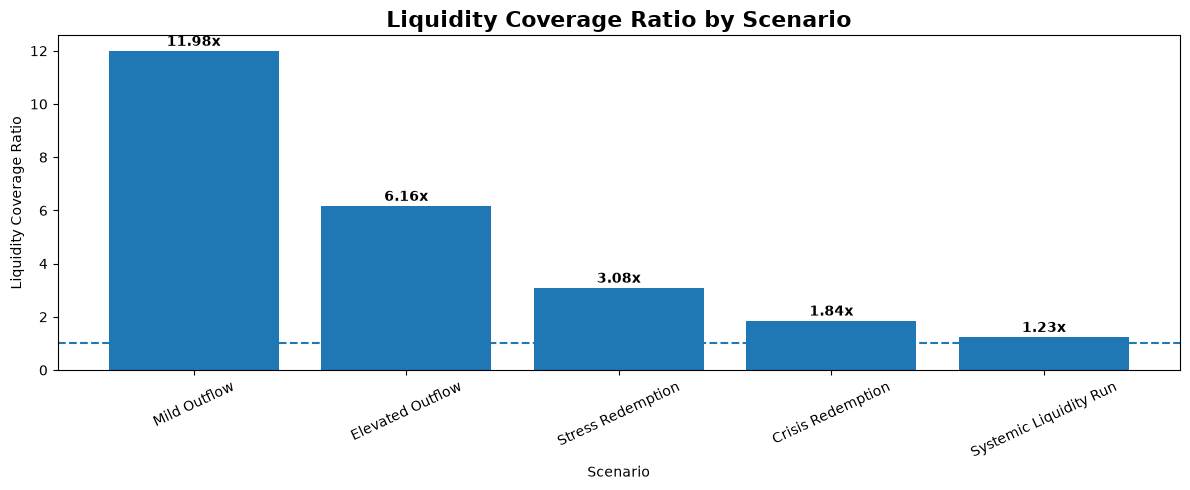

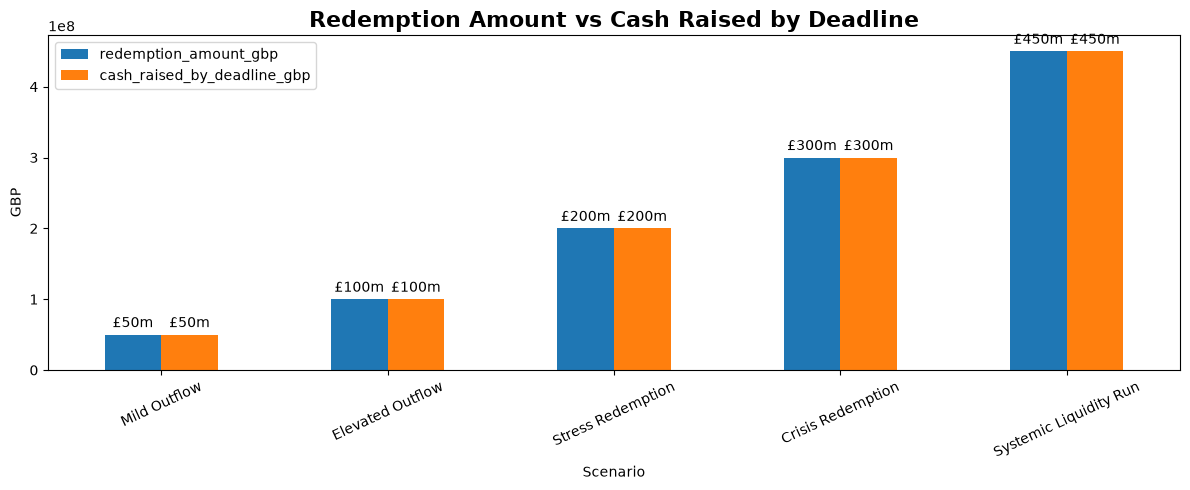

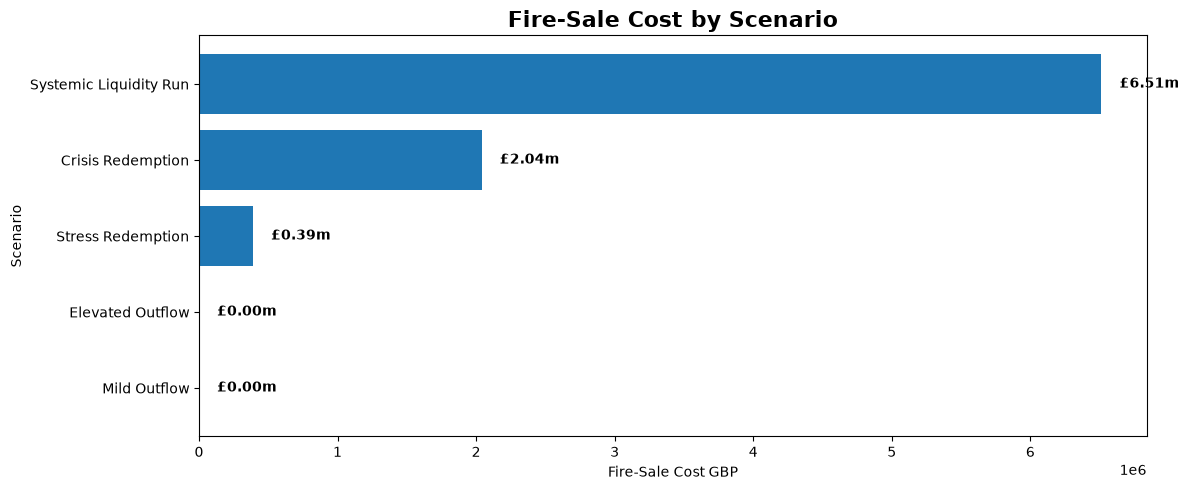

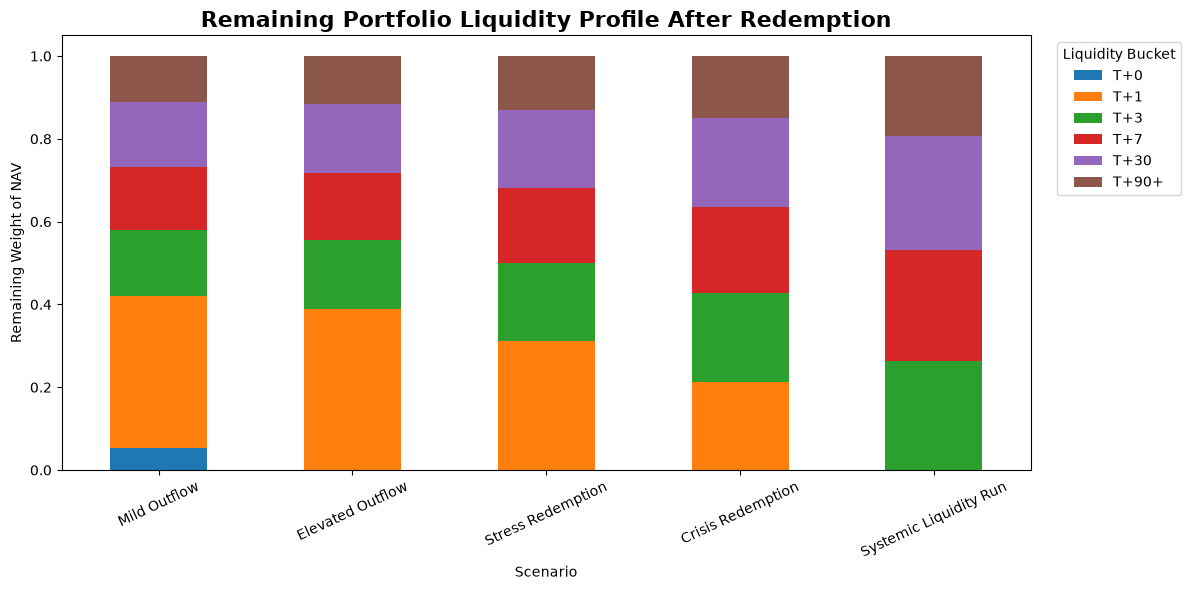

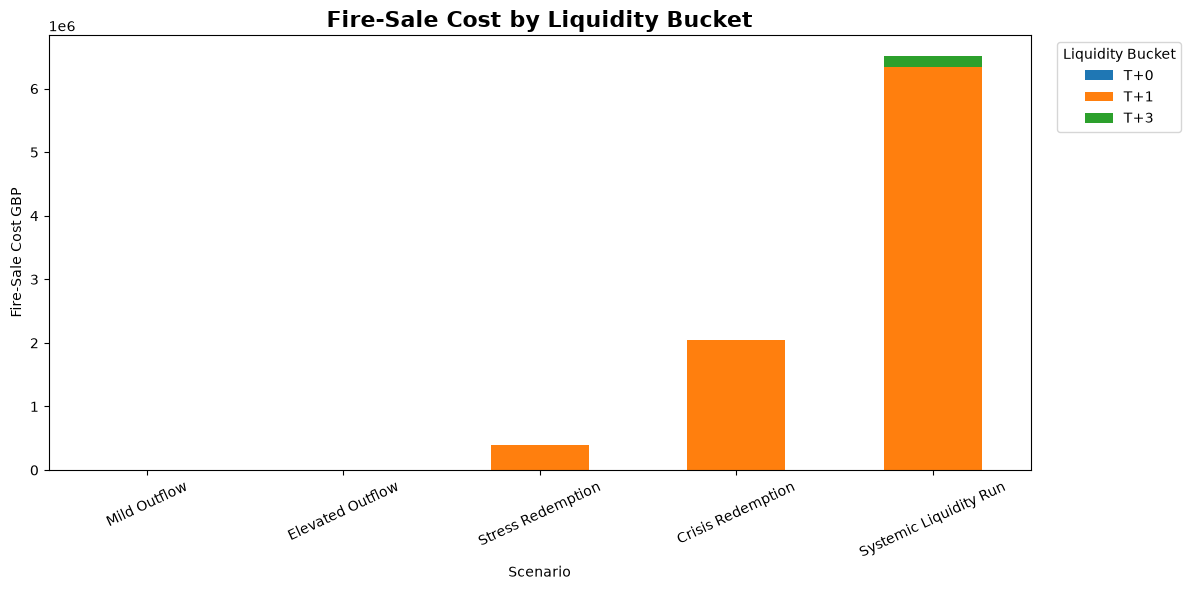

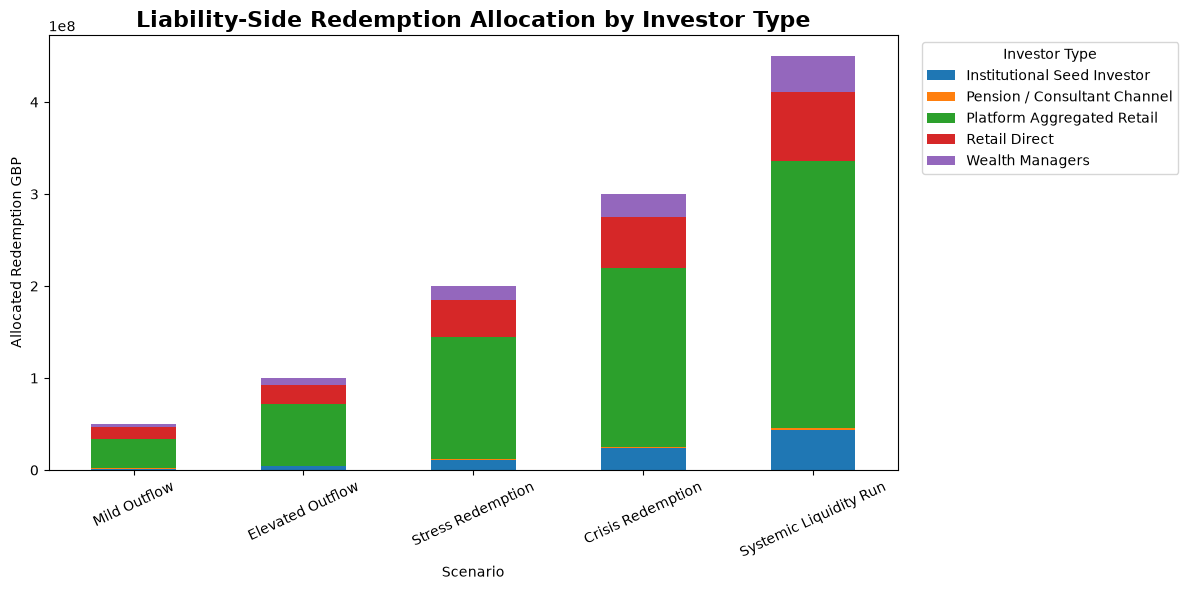

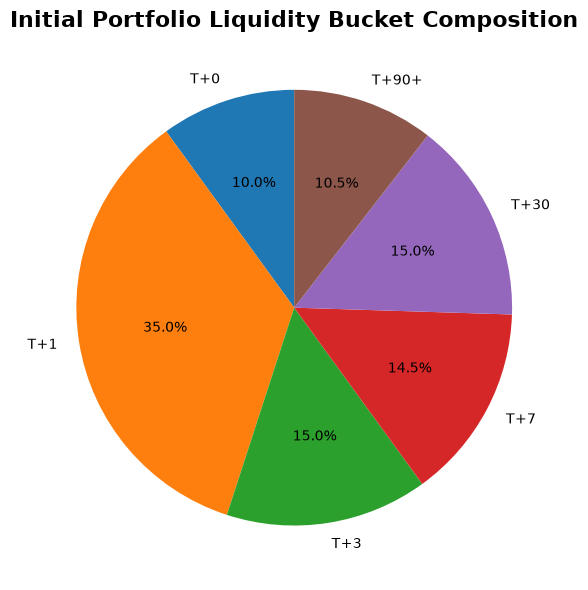

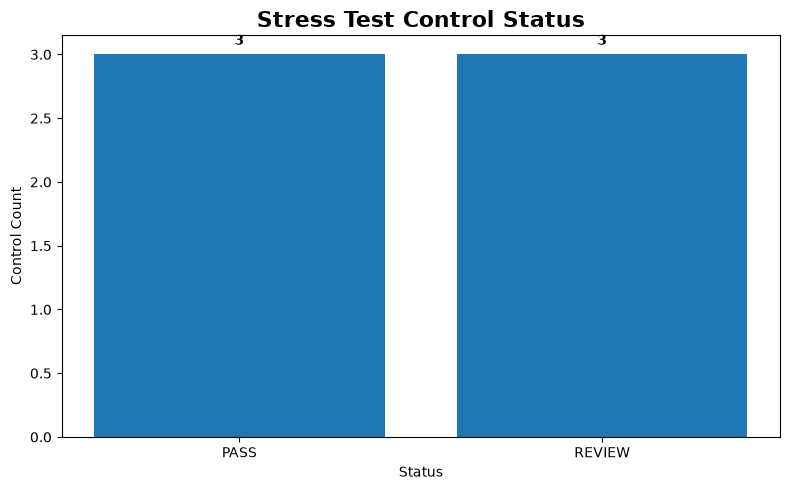

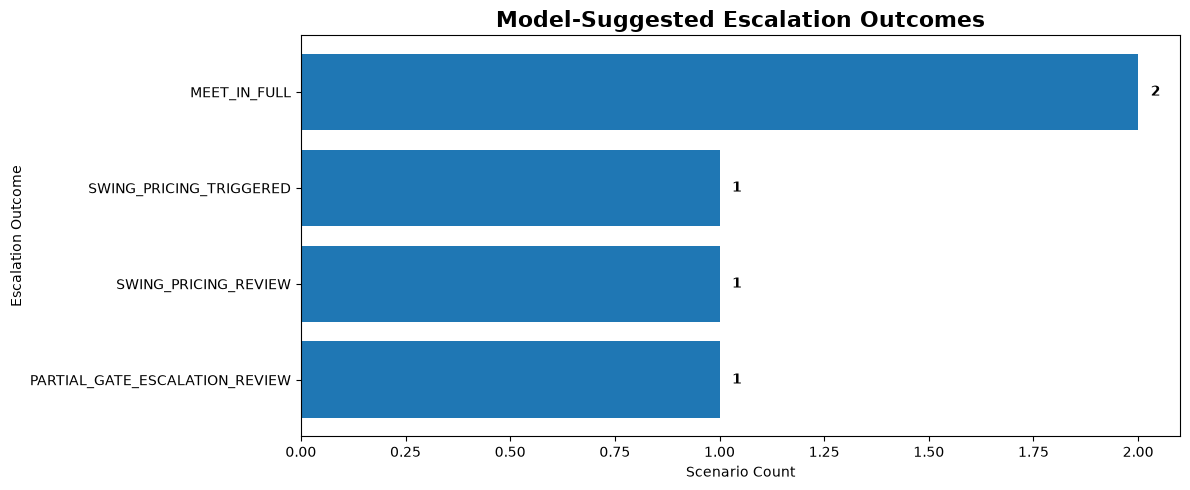

VISUAL ANALYTICS COMPLETE
Charts created: 9
Output folder:  /Users/ludmilaaboud/Desktop/MSc HW/Others/fund-liquidity-stress-engine/outputs


,chart_name,file_name,path
0,Liquidity Coverage Ratio by Scenario,lcr_by_scenario.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
1,Redemption Amount vs Cash Raised,redemption_vs_cash_raised.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
2,Fire-Sale Cost by Scenario,fire_sale_cost_by_scenario.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
3,Remaining Liquidity Profile,remaining_liquidity_profile.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
4,Fire-Sale Cost by Liquidity Bucket,fire_sale_cost_by_bucket.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
5,Investor Redemption Allocation,investor_redemption_allocation.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
6,Initial Liquidity Bucket Composition,liquidity_bucket_composition.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
7,Stress Test Control Status,stress_test_control_status.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...
8,Model-Suggested Escalation Outcomes,escalation_outcomes.png,/Users/ludmilaaboud/Desktop/MSc HW/Others/fund...


In [6]:
# ============================================================
# 6. Visual Analytics Dashboard
# Creates charts for liquidity stress reporting.
# ============================================================

chart_inventory = []

# ------------------------------------------------------------
# Chart helper
# ------------------------------------------------------------

def save_chart(file_name, chart_name):
    path = OUTPUT_DIR / file_name
    plt.savefig(path, dpi=300, bbox_inches="tight")
    chart_inventory.append({
        "chart_name": chart_name,
        "file_name": file_name,
        "path": str(path),
    })
    return path


# ------------------------------------------------------------
# Chart 1 — Liquidity Coverage Ratio by Scenario
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

plot_df = scenario_decision_summary.copy()
plot_df = plot_df.sort_values("redemption_pct_of_nav")

bars = ax.bar(
    plot_df["scenario_name"],
    plot_df["liquidity_coverage_ratio"],
)

ax.axhline(1.0, linewidth=1.5, linestyle="--")
ax.set_title("Liquidity Coverage Ratio by Scenario", fontsize=16, fontweight="bold")
ax.set_ylabel("Liquidity Coverage Ratio")
ax.set_xlabel("Scenario")
ax.tick_params(axis="x", rotation=25)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.08,
        f"{height:.2f}x",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
save_chart("lcr_by_scenario.png", "Liquidity Coverage Ratio by Scenario")
plt.show()


# ------------------------------------------------------------
# Chart 2 — Redemption Amount vs Cash Raised
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

comparison_df = scenario_decision_summary[
    ["scenario_name", "redemption_amount_gbp", "cash_raised_by_deadline_gbp"]
].copy()

comparison_df.set_index("scenario_name").plot(kind="bar", ax=ax)

ax.set_title("Redemption Amount vs Cash Raised by Deadline", fontsize=16, fontweight="bold")
ax.set_ylabel("GBP")
ax.set_xlabel("Scenario")
ax.tick_params(axis="x", rotation=25)

for container in ax.containers:
    ax.bar_label(container, labels=[f"£{v.get_height()/1_000_000:.0f}m" for v in container], padding=3)

plt.tight_layout()
save_chart("redemption_vs_cash_raised.png", "Redemption Amount vs Cash Raised")
plt.show()


# ------------------------------------------------------------
# Chart 3 — Fire-Sale Cost by Scenario
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

fire_plot = scenario_decision_summary.sort_values("fire_sale_cost_gbp")

bars = ax.barh(
    fire_plot["scenario_name"],
    fire_plot["fire_sale_cost_gbp"],
)

ax.set_title("Fire-Sale Cost by Scenario", fontsize=16, fontweight="bold")
ax.set_xlabel("Fire-Sale Cost GBP")
ax.set_ylabel("Scenario")

max_cost = fire_plot["fire_sale_cost_gbp"].max()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_cost * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"£{width/1_000_000:.2f}m",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
save_chart("fire_sale_cost_by_scenario.png", "Fire-Sale Cost by Scenario")
plt.show()


# ------------------------------------------------------------
# Chart 4 — Remaining Liquidity Profile After Redemption
# ------------------------------------------------------------

remaining_profile_plot = remaining_liquidity_profile.pivot_table(
    index="scenario_name",
    columns="liquidity_bucket",
    values="remaining_weight_of_nav",
    aggfunc="sum",
).fillna(0)

bucket_order = ["T+0", "T+1", "T+3", "T+7", "T+30", "T+90+"]
remaining_profile_plot = remaining_profile_plot[
    [bucket for bucket in bucket_order if bucket in remaining_profile_plot.columns]
]

scenario_order = scenario_decision_summary.sort_values("redemption_pct_of_nav")["scenario_name"].tolist()
remaining_profile_plot = remaining_profile_plot.loc[scenario_order]

fig, ax = plt.subplots(figsize=(12, 6))

remaining_profile_plot.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Remaining Portfolio Liquidity Profile After Redemption", fontsize=16, fontweight="bold")
ax.set_ylabel("Remaining Weight of NAV")
ax.set_xlabel("Scenario")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Liquidity Bucket", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_chart("remaining_liquidity_profile.png", "Remaining Liquidity Profile")
plt.show()


# ------------------------------------------------------------
# Chart 5 — Fire-Sale Cost by Liquidity Bucket
# ------------------------------------------------------------

fire_bucket_plot = fire_sale_cost_by_bucket.pivot_table(
    index="scenario_name",
    columns="liquidity_bucket",
    values="fire_sale_cost_gbp",
    aggfunc="sum",
).fillna(0)

fire_bucket_plot = fire_bucket_plot[
    [bucket for bucket in bucket_order if bucket in fire_bucket_plot.columns]
]

fire_bucket_plot = fire_bucket_plot.loc[scenario_order]

fig, ax = plt.subplots(figsize=(12, 6))

fire_bucket_plot.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Fire-Sale Cost by Liquidity Bucket", fontsize=16, fontweight="bold")
ax.set_ylabel("Fire-Sale Cost GBP")
ax.set_xlabel("Scenario")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Liquidity Bucket", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_chart("fire_sale_cost_by_bucket.png", "Fire-Sale Cost by Liquidity Bucket")
plt.show()


# ------------------------------------------------------------
# Chart 6 — Investor Redemption Allocation
# ------------------------------------------------------------

investor_plot = liability_side_summary.pivot_table(
    index="scenario_name",
    columns="investor_type",
    values="allocated_redemption_gbp",
    aggfunc="sum",
).fillna(0)

investor_plot = investor_plot.loc[scenario_order]

fig, ax = plt.subplots(figsize=(12, 6))

investor_plot.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Liability-Side Redemption Allocation by Investor Type", fontsize=16, fontweight="bold")
ax.set_ylabel("Allocated Redemption GBP")
ax.set_xlabel("Scenario")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Investor Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_chart("investor_redemption_allocation.png", "Investor Redemption Allocation")
plt.show()


# ------------------------------------------------------------
# Chart 7 — Initial Portfolio Liquidity Bucket Composition
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

bucket_composition = liquidity_bucket_summary.sort_values("bucket_days").copy()

wedges, texts, autotexts = ax.pie(
    bucket_composition["market_value_gbp"],
    labels=bucket_composition["liquidity_bucket"],
    autopct="%1.1f%%",
    startangle=90,
)

ax.set_title("Initial Portfolio Liquidity Bucket Composition", fontsize=16, fontweight="bold")

plt.tight_layout()
save_chart("liquidity_bucket_composition.png", "Initial Liquidity Bucket Composition")
plt.show()


# ------------------------------------------------------------
# Chart 8 — Stress Test Control Status
# ------------------------------------------------------------

control_status_plot = (
    stress_test_controls
    .groupby("status", as_index=False)
    .agg(control_count=("control", "count"))
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    control_status_plot["status"],
    control_status_plot["control_count"],
)

ax.set_title("Stress Test Control Status", fontsize=16, fontweight="bold")
ax.set_ylabel("Control Count")
ax.set_xlabel("Status")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
save_chart("stress_test_control_status.png", "Stress Test Control Status")
plt.show()


# ------------------------------------------------------------
# Chart 9 — Escalation Outcome Distribution
# ------------------------------------------------------------

escalation_plot = (
    liquidity_risk_diagnostics
    .groupby("model_suggested_escalation", as_index=False)
    .agg(scenario_count=("scenario_id", "count"))
    .sort_values("scenario_count")
)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.barh(
    escalation_plot["model_suggested_escalation"],
    escalation_plot["scenario_count"],
)

ax.set_title("Model-Suggested Escalation Outcomes", fontsize=16, fontweight="bold")
ax.set_xlabel("Scenario Count")
ax.set_ylabel("Escalation Outcome")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
save_chart("escalation_outcomes.png", "Model-Suggested Escalation Outcomes")
plt.show()


# ------------------------------------------------------------
# Chart inventory
# ------------------------------------------------------------

chart_inventory = pd.DataFrame(chart_inventory)

print("=" * 80)
print("VISUAL ANALYTICS COMPLETE")
print("=" * 80)
print(f"Charts created: {len(chart_inventory)}")
print(f"Output folder:  {OUTPUT_DIR}")
print("=" * 80)

display(chart_inventory)

In [8]:
# ============================================================
# 7. Excel Reporting Export Package
# Exports the full liquidity stress engine output into a structured workbook.
# ============================================================

from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

export_path = OUTPUT_DIR / "liquidity_stress_report.xlsx"

# ------------------------------------------------------------
# Export table dictionary
# ------------------------------------------------------------

export_tables = {
    "Executive_KPIs": executive_liquidity_kpis,
    "Executive_KPIs_Wide": executive_liquidity_kpis_wide,
    "Stress_Test_Controls": stress_test_controls,
    "Risk_Diagnostics": liquidity_risk_diagnostics,
    "Risk_Band_Summary": liquidity_risk_band_summary,
    "Escalation_Summary": escalation_summary,

    "Fund_Master": fund_master,
    "Holdings": holdings,
    "Holdings_Enriched": holdings_enriched,
    "Investor_Base": investor_base,
    "Investor_Base_Summary": investor_base_summary,
    "Redemption_Scenarios": redemption_scenarios,

    "Liquidity_Assumptions": liquidity_assumptions,
    "Validation_Controls": validation_controls,
    "Liquidity_Bucket_Summary": liquidity_bucket_summary,
    "Asset_Class_Summary": asset_class_summary,
    "Market_Depth_Summary": market_depth_summary,
    "Liquidity_Horizon_Capacity": liquidity_horizon_capacity,

    "Liquidation_Waterfall": liquidation_waterfall,
    "Scenario_Liquidity_Summary": scenario_liquidity_summary,
    "Scenario_Decision_Summary": scenario_decision_summary,
    "LCR_Scenario_Horizon": lcr_by_scenario_horizon,
    "Fire_Sale_By_Bucket": fire_sale_cost_by_bucket,
    "Remaining_Liquidity": remaining_liquidity_profile,

    "Investor_Redemption": investor_redemption_allocation,
    "Liability_Side_Summary": liability_side_summary,
    "Chart_Inventory": chart_inventory,
}

# ------------------------------------------------------------
# Clean export tables safely
# ------------------------------------------------------------

clean_export_tables = {}

for sheet_name, table in export_tables.items():
    clean_table = table.copy(deep=True)

    # Replace infinite values safely column by column
    for col in clean_table.columns:
        if pd.api.types.is_numeric_dtype(clean_table[col]):
            clean_table[col] = clean_table[col].replace(
                {
                    np.inf: np.nan,
                    -np.inf: np.nan,
                }
            )

        if pd.api.types.is_datetime64_any_dtype(clean_table[col]):
            clean_table[col] = clean_table[col].dt.strftime("%Y-%m-%d %H:%M:%S")

    clean_table = clean_table.where(pd.notna(clean_table), "")

    clean_export_tables[sheet_name] = clean_table

# ------------------------------------------------------------
# Write workbook
# ------------------------------------------------------------

with pd.ExcelWriter(export_path, engine="openpyxl") as writer:
    for sheet_name, table in clean_export_tables.items():
        safe_sheet_name = sheet_name[:31]
        table.to_excel(writer, sheet_name=safe_sheet_name, index=False)

    workbook = writer.book

    header_fill = PatternFill(start_color="263238", end_color="263238", fill_type="solid")
    header_font = Font(color="FFFFFF", bold=True)
    sub_fill = PatternFill(start_color="F7F4EF", end_color="F7F4EF", fill_type="solid")

    thin_border = Border(
        left=Side(style="thin", color="D9D9D9"),
        right=Side(style="thin", color="D9D9D9"),
        top=Side(style="thin", color="D9D9D9"),
        bottom=Side(style="thin", color="D9D9D9"),
    )

    for worksheet in workbook.worksheets:
        worksheet.freeze_panes = "A2"

        if worksheet.max_row > 1 and worksheet.max_column > 1:
            worksheet.auto_filter.ref = worksheet.dimensions

        # Header styling
        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            cell.border = thin_border

        # Body styling
        for row in worksheet.iter_rows(min_row=2):
            for cell in row:
                cell.border = thin_border
                cell.alignment = Alignment(vertical="center", wrap_text=True)

                if isinstance(cell.value, float):
                    cell.number_format = '#,##0.00'

                if isinstance(cell.value, int):
                    cell.number_format = '#,##0'

        # Column widths
        for column_cells in worksheet.columns:
            column_letter = get_column_letter(column_cells[0].column)
            max_length = 0

            for cell in column_cells:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))

            worksheet.column_dimensions[column_letter].width = min(max_length + 2, 45)

        # First column subtle fill
        for cell in worksheet["A"]:
            if cell.row != 1:
                cell.fill = sub_fill

print("=" * 80)
print("EXCEL REPORTING EXPORT COMPLETE")
print("=" * 80)
print(f"Excel export saved to: {export_path}")
print(f"Sheets exported:       {len(clean_export_tables)}")
print("=" * 80)

print("Exported sheets:")
for sheet_name in clean_export_tables.keys():
    print(f"- {sheet_name[:31]}")
print("=" * 80)

EXCEL REPORTING EXPORT COMPLETE
Excel export saved to: /Users/ludmilaaboud/Desktop/MSc HW/Others/fund-liquidity-stress-engine/outputs/liquidity_stress_report.xlsx
Sheets exported:       27
Exported sheets:
- Executive_KPIs
- Executive_KPIs_Wide
- Stress_Test_Controls
- Risk_Diagnostics
- Risk_Band_Summary
- Escalation_Summary
- Fund_Master
- Holdings
- Holdings_Enriched
- Investor_Base
- Investor_Base_Summary
- Redemption_Scenarios
- Liquidity_Assumptions
- Validation_Controls
- Liquidity_Bucket_Summary
- Asset_Class_Summary
- Market_Depth_Summary
- Liquidity_Horizon_Capacity
- Liquidation_Waterfall
- Scenario_Liquidity_Summary
- Scenario_Decision_Summary
- LCR_Scenario_Horizon
- Fire_Sale_By_Bucket
- Remaining_Liquidity
- Investor_Redemption
- Liability_Side_Summary
- Chart_Inventory


In [9]:
# ============================================================
# 8. Executive Summary + Project Completion
# Creates a written executive summary for the liquidity stress engine.
# ============================================================

minimum_lcr = executive_liquidity_kpis_wide.loc[0, "minimum_lcr"]
worst_lcr_scenario = executive_liquidity_kpis_wide.loc[0, "worst_lcr_scenario"]
maximum_fire_sale_cost = executive_liquidity_kpis_wide.loc[0, "maximum_fire_sale_cost_gbp"]
worst_fire_sale_scenario = executive_liquidity_kpis_wide.loc[0, "worst_fire_sale_scenario"]
weakest_remaining_liquidity_ratio = executive_liquidity_kpis_wide.loc[0, "weakest_remaining_liquidity_ratio"]
systemic_run_outcome = executive_liquidity_kpis_wide.loc[0, "systemic_run_outcome"]

scenarios_tested = int(executive_liquidity_kpis_wide.loc[0, "redemption_scenarios_tested"])
scenarios_met_in_full = int(executive_liquidity_kpis_wide.loc[0, "scenarios_met_in_full"])
scenarios_requiring_escalation = int(executive_liquidity_kpis_wide.loc[0, "scenarios_requiring_escalation"])
high_critical_scenarios = int(executive_liquidity_kpis_wide.loc[0, "high_critical_scenarios"])
watchlist_holdings_count = int(executive_liquidity_kpis_wide.loc[0, "watchlist_holdings"])
invalid_holdings_count = int(executive_liquidity_kpis_wide.loc[0, "invalid_holdings"])

systemic_summary = liquidity_risk_diagnostics[
    liquidity_risk_diagnostics["scenario_id"] == "S5"
].iloc[0]

crisis_summary = liquidity_risk_diagnostics[
    liquidity_risk_diagnostics["scenario_id"] == "S4"
].iloc[0]

stress_summary = liquidity_risk_diagnostics[
    liquidity_risk_diagnostics["scenario_id"] == "S3"
].iloc[0]

executive_summary_text = f"""
FUND LIQUIDITY MISMATCH STRESS ENGINE — EXECUTIVE SUMMARY

Stress date:
- {STRESS_DATE.date()}

Fund:
- {fund_master.loc[0, "fund_name"]}
- Fund type: {fund_master.loc[0, "fund_type"]}
- Base currency: {BASE_CURRENCY}
- Dealing frequency: {fund_master.loc[0, "dealing_frequency"]}
- Redemption notice days: {fund_master.loc[0, "redemption_notice_days"]}

Fund size:
- Fund NAV: £{fund_nav_gbp:,.2f}
- Number of holdings: {len(holdings_enriched)}
- Watchlist holdings: {watchlist_holdings_count}
- Invalid holdings: {invalid_holdings_count}

Initial liquidity profile:
- T+0 assets: £{liquidity_bucket_summary.loc[liquidity_bucket_summary["liquidity_bucket"] == "T+0", "market_value_gbp"].iloc[0]:,.2f}
- T+1 assets: £{liquidity_bucket_summary.loc[liquidity_bucket_summary["liquidity_bucket"] == "T+1", "market_value_gbp"].iloc[0]:,.2f}
- T+3 assets: £{liquidity_bucket_summary.loc[liquidity_bucket_summary["liquidity_bucket"] == "T+3", "market_value_gbp"].iloc[0]:,.2f}
- T+7 assets: £{liquidity_bucket_summary.loc[liquidity_bucket_summary["liquidity_bucket"] == "T+7", "market_value_gbp"].iloc[0]:,.2f}
- T+30 assets: £{liquidity_bucket_summary.loc[liquidity_bucket_summary["liquidity_bucket"] == "T+30", "market_value_gbp"].iloc[0]:,.2f}
- T+90+ assets: £{liquidity_bucket_summary.loc[liquidity_bucket_summary["liquidity_bucket"] == "T+90+", "market_value_gbp"].iloc[0]:,.2f}

Stress testing outcome:
- Redemption scenarios tested: {scenarios_tested}
- Scenarios met in full: {scenarios_met_in_full}
- Scenarios requiring escalation: {scenarios_requiring_escalation}
- High / critical liquidity scenarios: {high_critical_scenarios}
- Minimum liquidity coverage ratio: {minimum_lcr:,.2f}x
- Worst LCR scenario: {worst_lcr_scenario}
- Maximum fire-sale cost: £{maximum_fire_sale_cost:,.2f}
- Worst fire-sale scenario: {worst_fire_sale_scenario}
- Weakest remaining liquidity ratio: {weakest_remaining_liquidity_ratio:,.2%}
- Systemic run outcome: {systemic_run_outcome}

Scenario interpretation:
1. Mild Outflow:
   - The fund meets the redemption in full using available liquidity.
   - No material fire-sale cost is generated.

2. Elevated Outflow:
   - The fund meets the redemption in full.
   - Liquidity remains sufficient under the tested horizon.

3. Stress Redemption:
   - The fund meets the redemption, but fire-sale cost emerges.
   - Model-suggested action: {stress_summary["model_suggested_escalation"]}

4. Crisis Redemption:
   - The fund meets the redemption, but forced selling becomes more material.
   - Fire-sale cost: £{crisis_summary["fire_sale_cost_gbp"]:,.2f}
   - Model-suggested action: {crisis_summary["model_suggested_escalation"]}

5. Systemic Liquidity Run:
   - The fund meets the redemption amount in this modelled run, but only by materially depleting liquid assets.
   - Redemption amount: £{systemic_summary["redemption_amount_gbp"]:,.2f}
   - Liquidity coverage ratio: {systemic_summary["liquidity_coverage_ratio"]:,.2f}x
   - Fire-sale cost: £{systemic_summary["fire_sale_cost_gbp"]:,.2f}
   - Remaining liquidity ratio: {systemic_summary["remaining_liquidity_ratio"]:,.2%}
   - Remaining illiquid ratio: {systemic_summary["remaining_illiquid_ratio"]:,.2%}
   - Model-suggested escalation: {systemic_summary["model_suggested_escalation"]}

Business interpretation:
The engine compares asset-side liquidity against liability-side redemption pressure.
It shows that the fund can meet mild and elevated outflows cleanly, but larger shocks require escalation because forced selling begins to create material dilution and leaves the remaining portfolio less liquid.

The systemic scenario is especially important. Even though the model raises enough cash by the deadline, the fund's residual liquidity profile weakens materially. This means the fund may survive the first redemption wave but become more vulnerable to a second wave of redemptions.

Final model conclusion:
- The fund does not experience a cash shortfall in the tested scenarios.
- The fund does experience material liquidity deterioration under severe redemption pressure.
- The systemic liquidity run requires liquidity committee escalation.
- The model-suggested outcome for the tail scenario is: {systemic_run_outcome}

Reporting outputs:
- Excel reporting pack: {export_path.name}
- Executive summary file: liquidity_stress_executive_summary.txt
- Charts created: {len(chart_inventory)}
- Workbook sheets exported: {len(clean_export_tables)}
"""

summary_path = OUTPUT_DIR / "liquidity_stress_executive_summary.txt"
summary_path.write_text(executive_summary_text, encoding="utf-8")

project_completion_summary = pd.DataFrame([
    {
        "section": "Fund data universe",
        "status": "Complete",
        "output": "Fund master, holdings, investor base and redemption scenarios created",
    },
    {
        "section": "Liquidity classification",
        "status": "Complete",
        "output": "Holdings classified into T+0, T+1, T+3, T+7, T+30 and T+90+ buckets",
    },
    {
        "section": "Liquidity assumptions",
        "status": "Complete",
        "output": "Transaction cost, stressed cost and market-depth assumptions created",
    },
    {
        "section": "Data validation",
        "status": "Complete",
        "output": f"{invalid_holdings_count} invalid holdings and {watchlist_holdings_count} watchlist holdings identified",
    },
    {
        "section": "Liquidation waterfall",
        "status": "Complete",
        "output": "Scenario-by-scenario sell-down waterfall created",
    },
    {
        "section": "Fire-sale cost engine",
        "status": "Complete",
        "output": f"Maximum fire-sale cost of £{maximum_fire_sale_cost:,.2f}",
    },
    {
        "section": "Liquidity coverage analysis",
        "status": "Complete",
        "output": f"Minimum LCR of {minimum_lcr:,.2f}x in {worst_lcr_scenario}",
    },
    {
        "section": "Remaining liquidity analysis",
        "status": "Complete",
        "output": f"Weakest remaining liquidity ratio of {weakest_remaining_liquidity_ratio:,.2%}",
    },
    {
        "section": "Escalation framework",
        "status": "Complete",
        "output": f"Systemic run outcome: {systemic_run_outcome}",
    },
    {
        "section": "Visual analytics",
        "status": "Complete",
        "output": f"{len(chart_inventory)} charts saved to outputs folder",
    },
    {
        "section": "Excel export",
        "status": "Complete",
        "output": f"{len(clean_export_tables)}-sheet reporting workbook exported",
    },
])

print("=" * 80)
print("EXECUTIVE SUMMARY COMPLETE")
print("=" * 80)
print(executive_summary_text)
print("=" * 80)
print(f"Executive summary saved to: {summary_path}")
print("=" * 80)

display(project_completion_summary)

EXECUTIVE SUMMARY COMPLETE

FUND LIQUIDITY MISMATCH STRESS ENGINE — EXECUTIVE SUMMARY

Stress date:
- 2027-03-31

Fund:
- Global Income Opportunities Fund
- Fund type: Open-Ended Multi-Asset Fund
- Base currency: GBP
- Dealing frequency: Daily
- Redemption notice days: 1

Fund size:
- Fund NAV: £1,000,000,000.00
- Number of holdings: 26
- Watchlist holdings: 8
- Invalid holdings: 0

Initial liquidity profile:
- T+0 assets: £100,000,000.00
- T+1 assets: £350,000,000.00
- T+3 assets: £150,000,000.00
- T+7 assets: £145,000,000.00
- T+30 assets: £150,000,000.00
- T+90+ assets: £105,000,000.00

Stress testing outcome:
- Redemption scenarios tested: 5
- Scenarios met in full: 2
- Scenarios requiring escalation: 3
- High / critical liquidity scenarios: 2
- Minimum liquidity coverage ratio: 1.23x
- Worst LCR scenario: Systemic Liquidity Run
- Maximum fire-sale cost: £6,513,019.36
- Worst fire-sale scenario: Systemic Liquidity Run
- Weakest remaining liquidity ratio: 53.08%
- Systemic run outco

,section,status,output
0,Fund data universe,Complete,"Fund master, holdings, investor base and redem..."
1,Liquidity classification,Complete,"Holdings classified into T+0, T+1, T+3, T+7, T..."
2,Liquidity assumptions,Complete,"Transaction cost, stressed cost and market-dep..."
3,Data validation,Complete,0 invalid holdings and 8 watchlist holdings id...
4,Liquidation waterfall,Complete,Scenario-by-scenario sell-down waterfall created
5,Fire-sale cost engine,Complete,"Maximum fire-sale cost of £6,513,019.36"
6,Liquidity coverage analysis,Complete,Minimum LCR of 1.23x in Systemic Liquidity Run
7,Remaining liquidity analysis,Complete,Weakest remaining liquidity ratio of 53.08%
8,Escalation framework,Complete,Systemic run outcome: PARTIAL_GATE_ESCALATION_...
9,Visual analytics,Complete,9 charts saved to outputs folder
